4週間分の可視化を行う


In [1]:
import polars as pl
import pandas as pd # 念の為importしておく
import matplotlib.pyplot as plt
import japanize_matplotlib 
from collections import defaultdict

In [2]:
df_202504 = pl.read_csv('/home/takizawa/2025_takizawa/2026_Competition/202504_od_data.csv')
df_202507 = pl.read_csv('/home/takizawa/2025_takizawa/2026_Competition/202507_od_data.csv')
df_202510 = pl.read_csv('/home/takizawa/2025_takizawa/2026_Competition/202510_od_data.csv')
df_202601 = pl.read_csv('/home/takizawa/2025_takizawa/2026_Competition/202601_od_data.csv')

In [3]:
# df_202504.head()

In [4]:
# 駅名，日付けを入力すると，利用者数の推移を出力する関数

def plot_dropoff_count_by_time(df, target_date, interval=30):
    """
    指定した乗車日に対して、降車時刻を一定間隔ごとに集計し、行数をプロットする関数。

    Parameters
    ----------
    df : polars.DataFrame
        対象のデータフレーム
    target_date : int
        抽出対象の乗車日。例: 20250407
    interval : int, default 30
        集計間隔。単位は分。
    """

    # 対象日のデータだけ抽出
    df_target = df.filter(
        pl.col("乗車日") == target_date
    )

    # 「降車時刻」列をリストとして取り出す
    dropoff_times = df_target["降車時刻"].to_list()

    # interval ごとのカウント用
    count_dict = defaultdict(int)

    # 1つずつ降車時刻を処理
    for time_str in dropoff_times:

        # 欠損値を除外
        if time_str is None:
            continue

        # 念のため文字列に変換
        time_str = str(time_str)

        # 空文字や不正な値を除外
        if ":" not in time_str:
            continue

        # ":" の前後で分割
        forward, backward = time_str.split(":")

        # int型に変換
        forward = int(forward)
        backward = int(backward)

        # 時刻を「0時からの経過分」に変換
        total_minutes = forward * 60 + backward

        # interval 分ごとの区間に変換
        time_bin = (total_minutes // interval) * interval

        # その区間の件数を1増やす
        count_dict[time_bin] += 1

    # プロット用に並び替え
    x = sorted(count_dict.keys())
    y = [count_dict[k] for k in x]

    # 横軸ラベルを HH:MM 形式にする
    x_labels = [
        f"{minute // 60:02d}:{minute % 60:02d}"
        for minute in x
    ]

    # プロット
    plt.figure(figsize=(12, 6))
    plt.bar(x, y, width=interval, align="edge")

    plt.xlabel(f"降車時刻 interval ({interval}分)")
    plt.ylabel("行数")
    plt.title(f"乗車日 {target_date} における降車時刻別行数")

    plt.xticks(x, x_labels, rotation=45)
    plt.grid(True)

    plt.show()

In [46]:
# 202504に対する抽出処理

# 20250414(Mon)~20250420(Sun)を抽出する
dates = (pl.col("乗車日") >= 20250414) & (pl.col("乗車日") <= 20250420)
df_filtered = df_202504.filter(dates)


# 降車駅：泉ケ丘駅を抽出する
izumigaoka = pl.col("降車駅") == "泉ケ丘"
df_filtered_izumigaoka = df_filtered.filter(izumigaoka)
# df_filtered_izumigaoka.head()


# 降車駅：鶴原駅を抽出する
turuhara = pl.col("降車駅") == "鶴原"
df_filtered_turuhara = df_filtered.filter(turuhara)
# df_filtered_turuhara.head()


# 降車駅：住吉大社駅を抽出する
sumiyoshi = pl.col("降車駅") == "住吉大社"
df_filtered_sumiyoshi = df_filtered.filter(sumiyoshi)
# df_filtered_sumiyoshi.head()



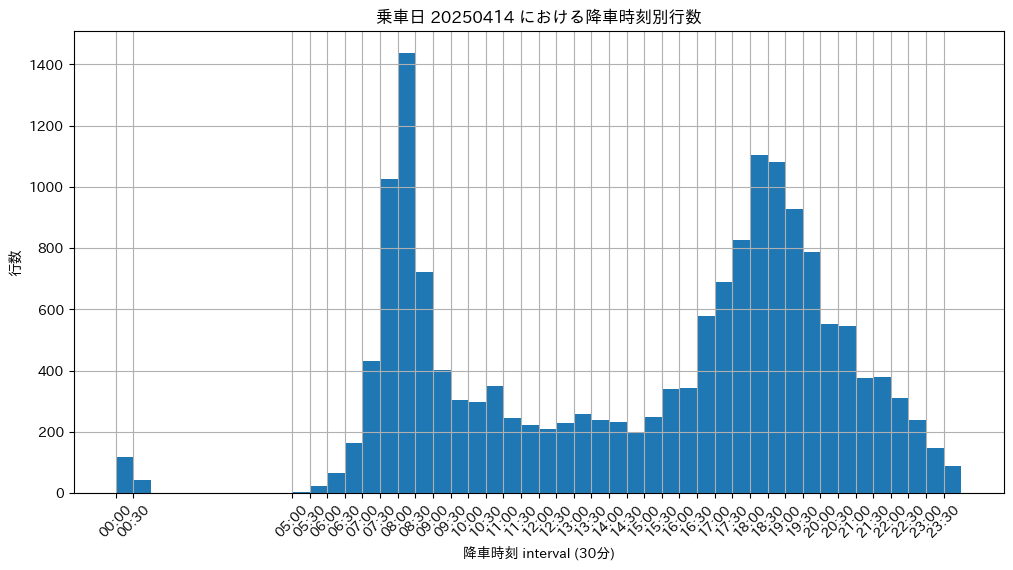

In [24]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250414
)

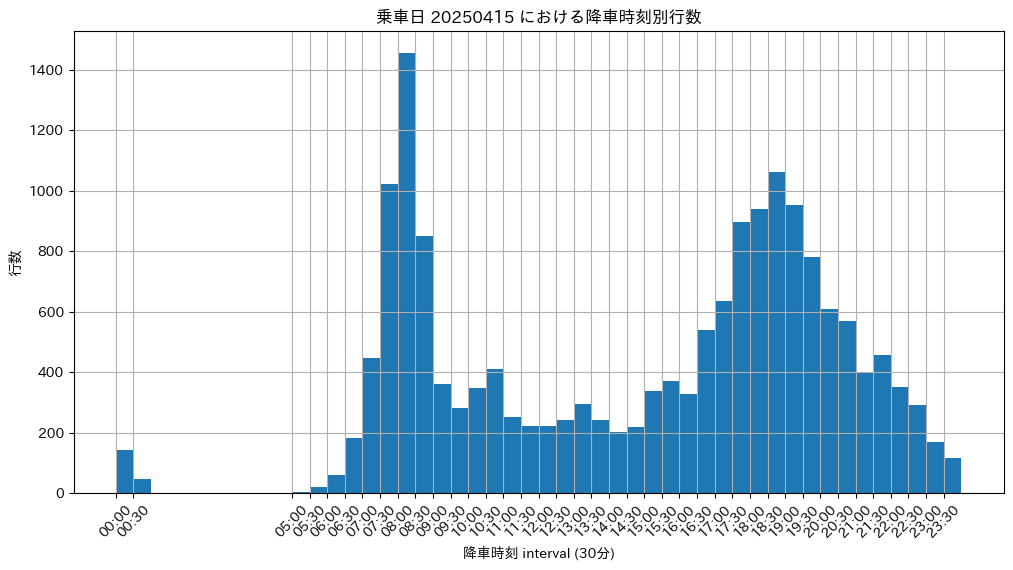

In [25]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250415
)

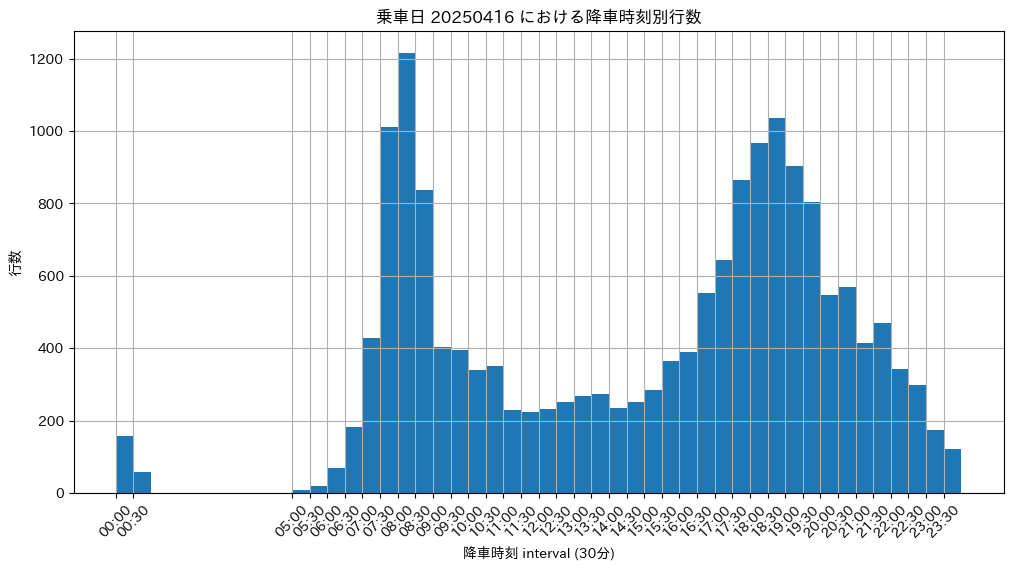

In [26]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250416
)

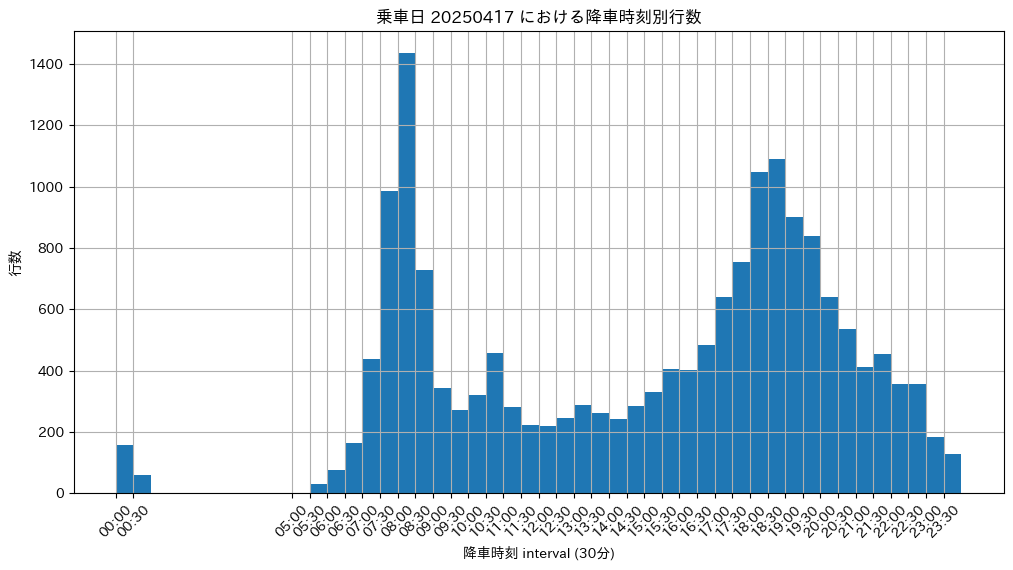

In [27]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250417
)

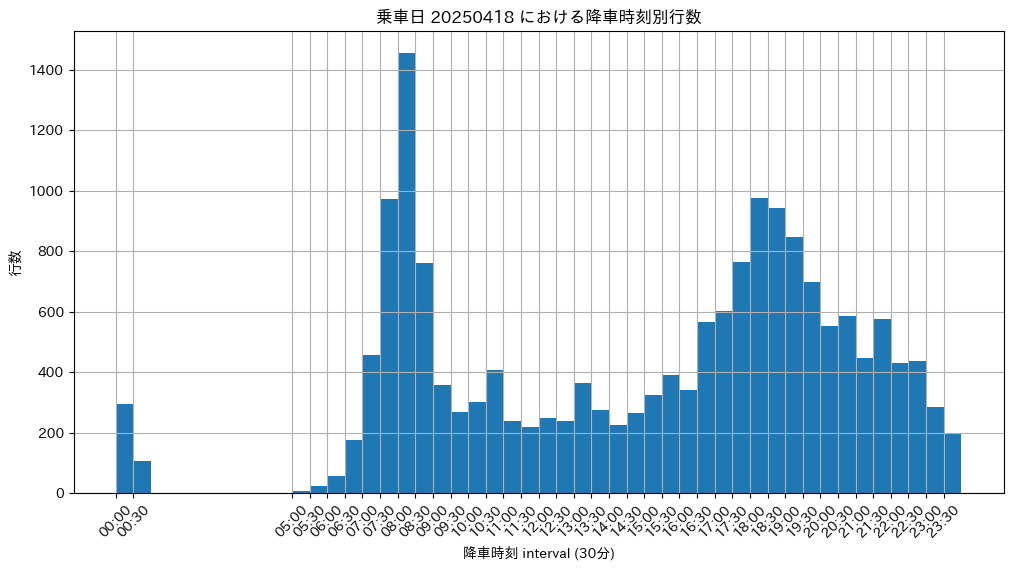

In [28]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250418
)

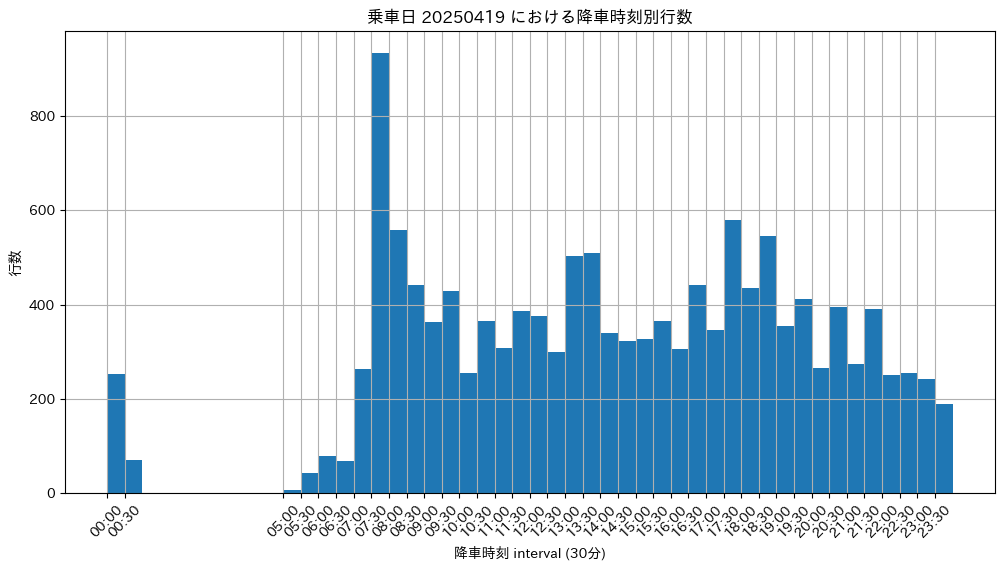

In [29]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250419
)

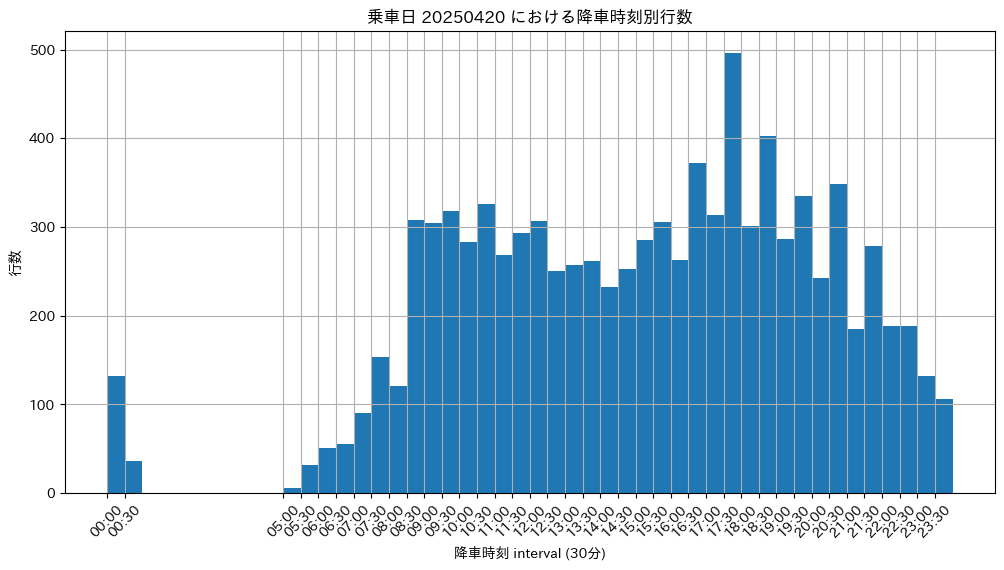

In [30]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250420
)

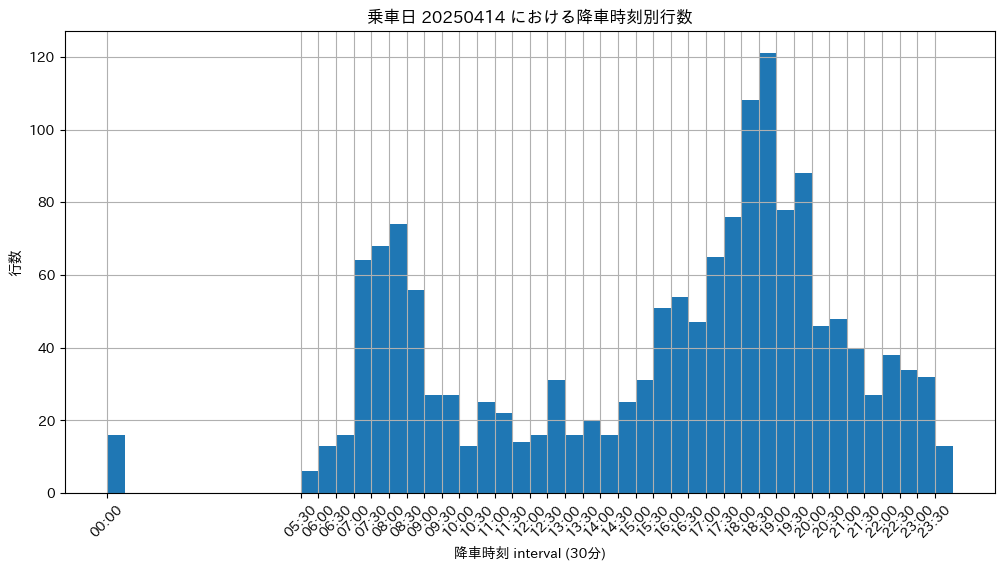

In [47]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250414
)

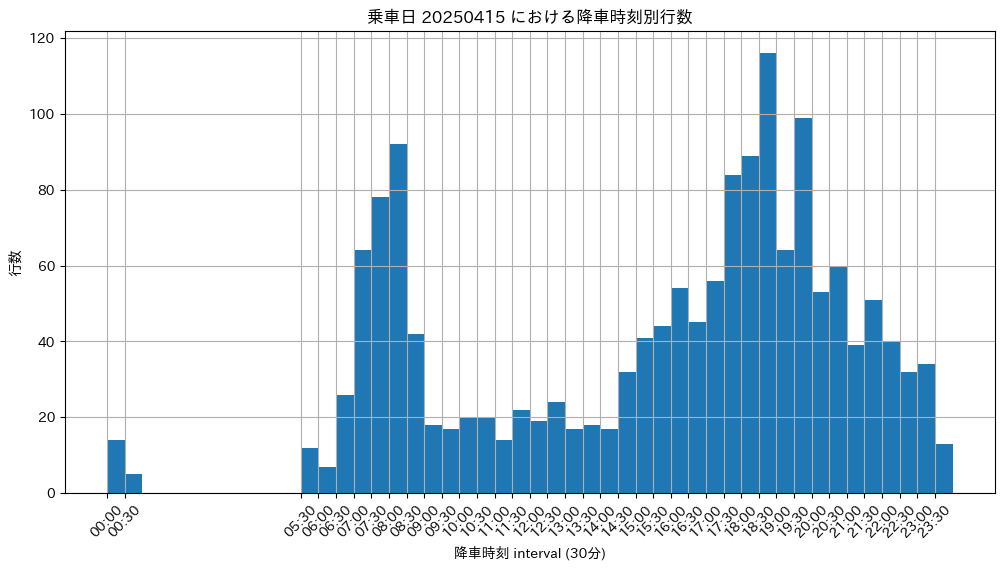

In [48]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250415
)

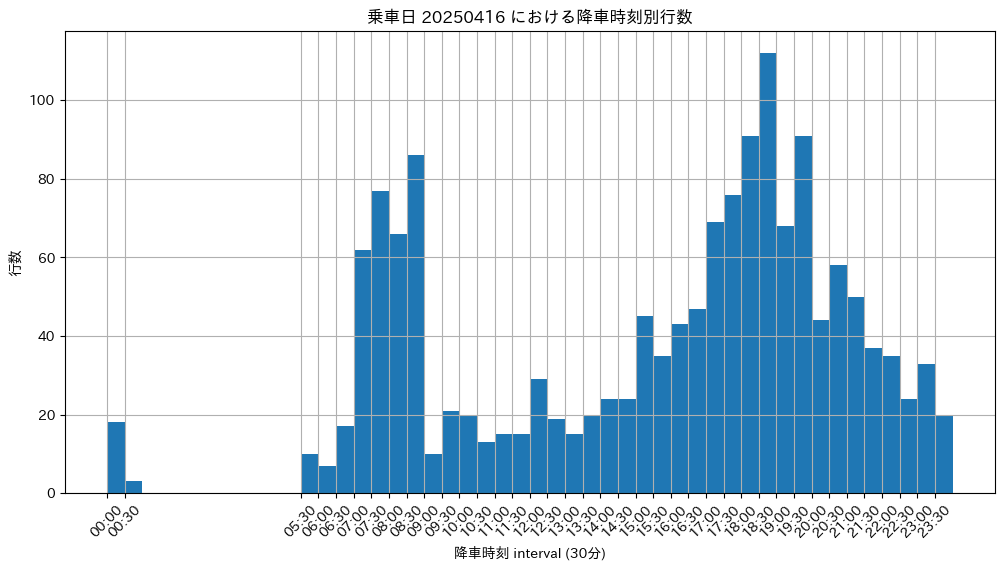

In [49]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250416
)

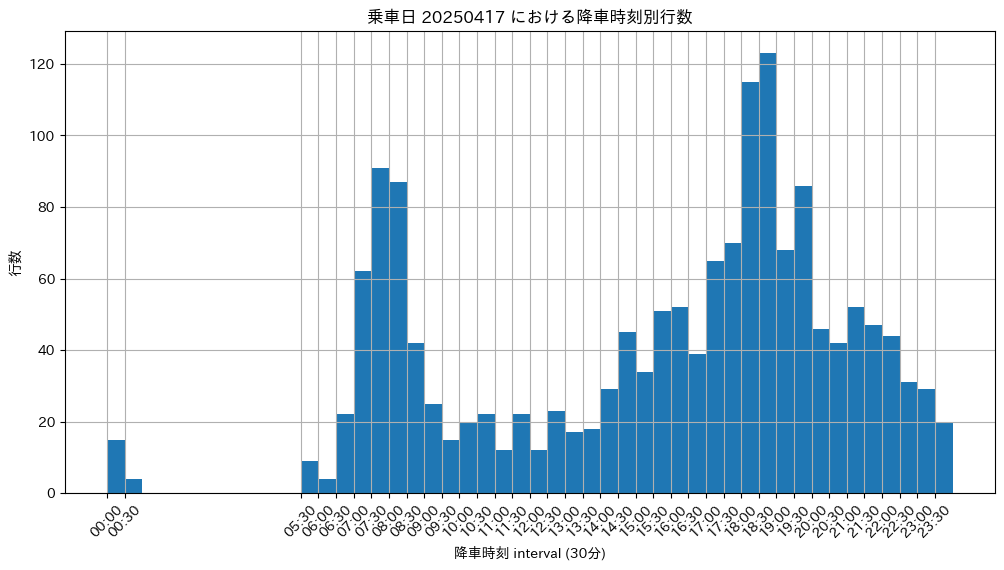

In [50]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250417
)

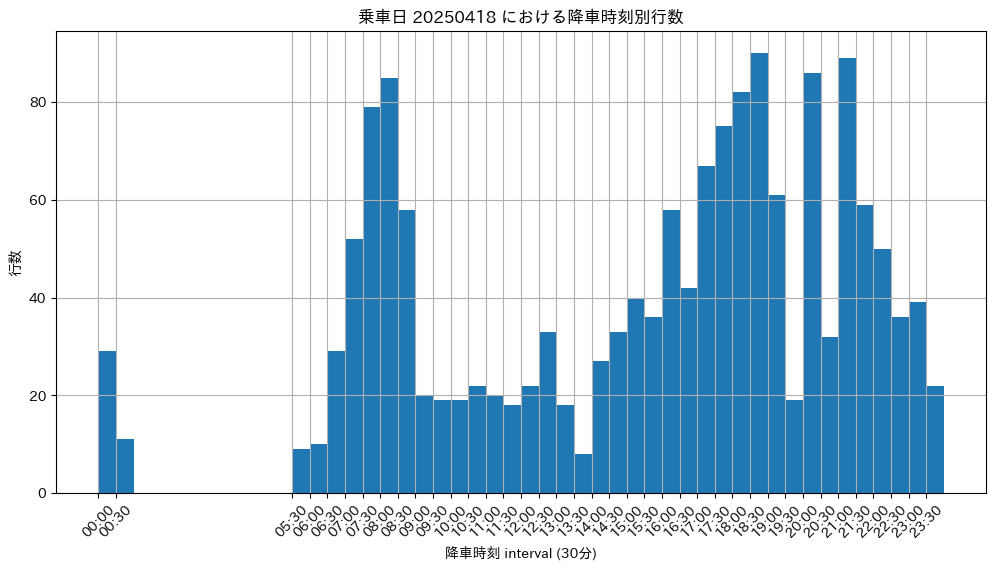

In [51]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250418
)

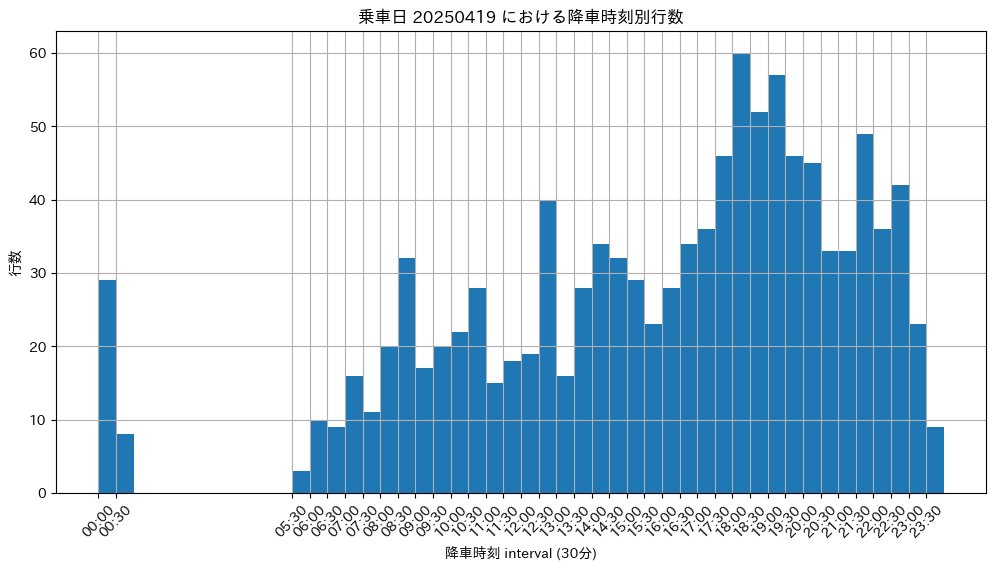

In [52]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250419
)

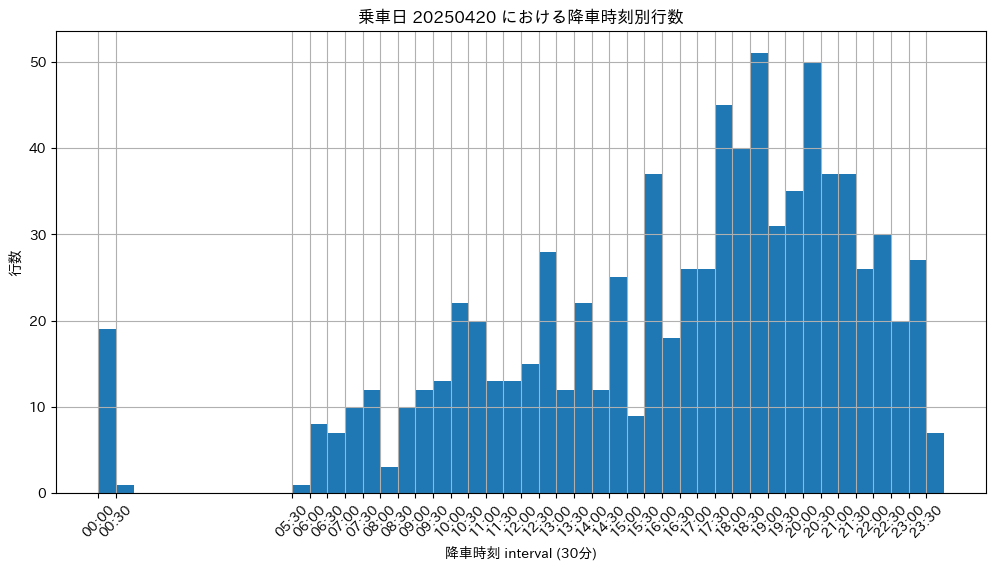

In [53]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250420
)

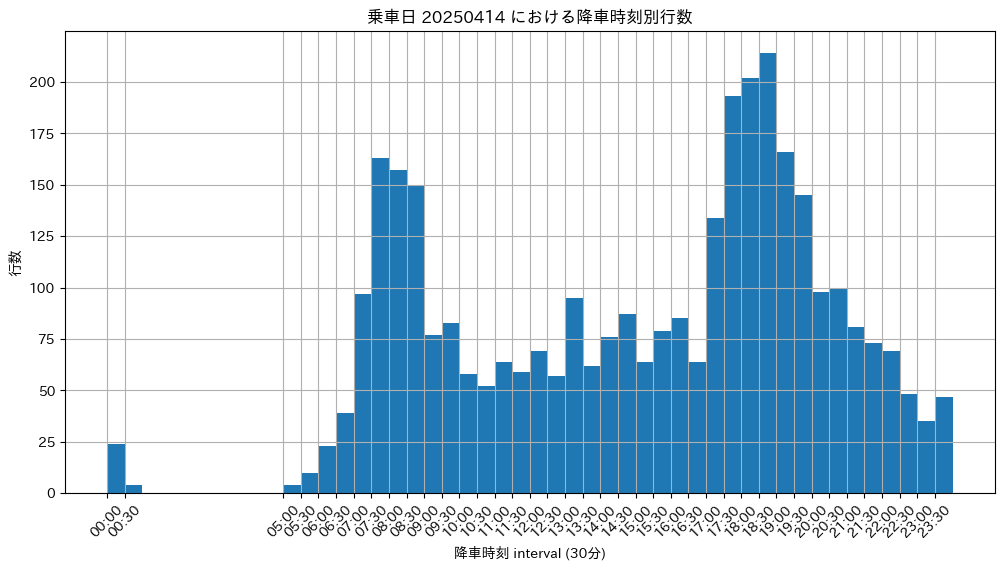

In [38]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250414
)

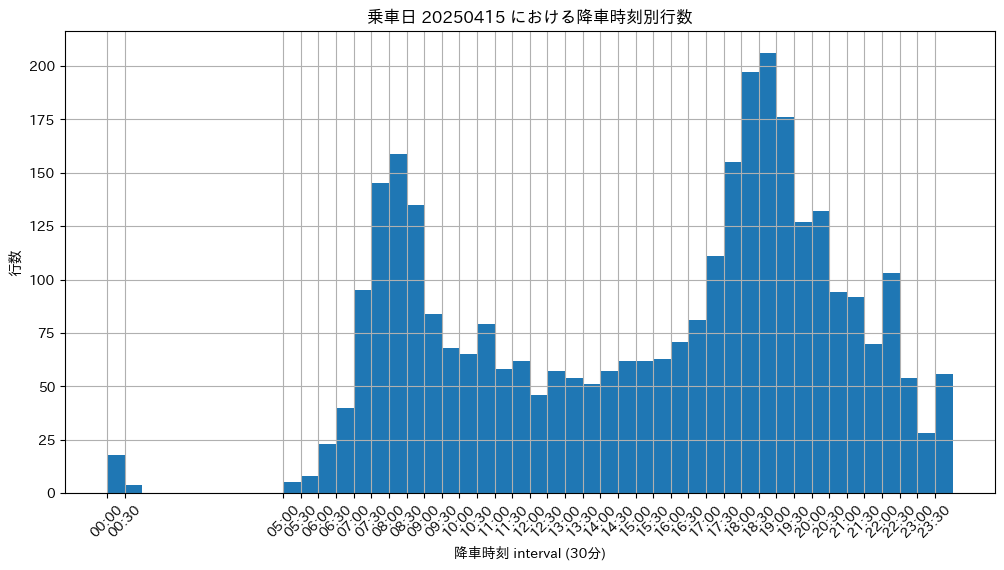

In [39]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250415
)

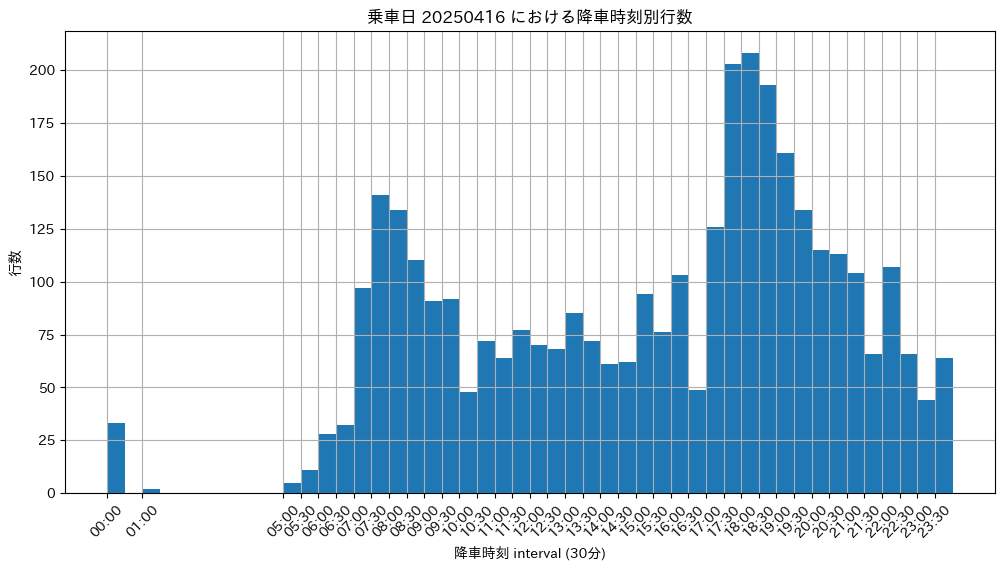

In [40]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250416
)

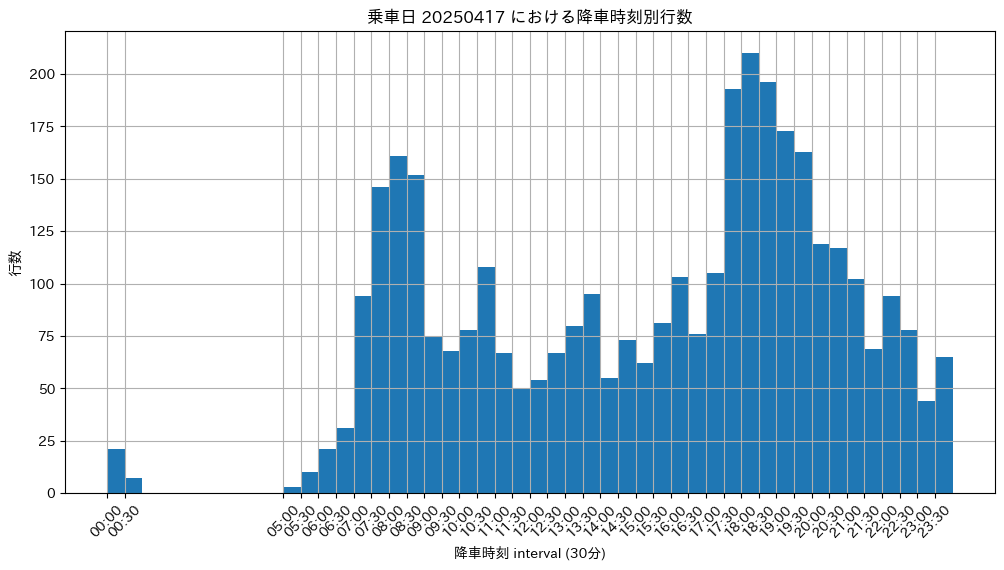

In [41]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250417
)

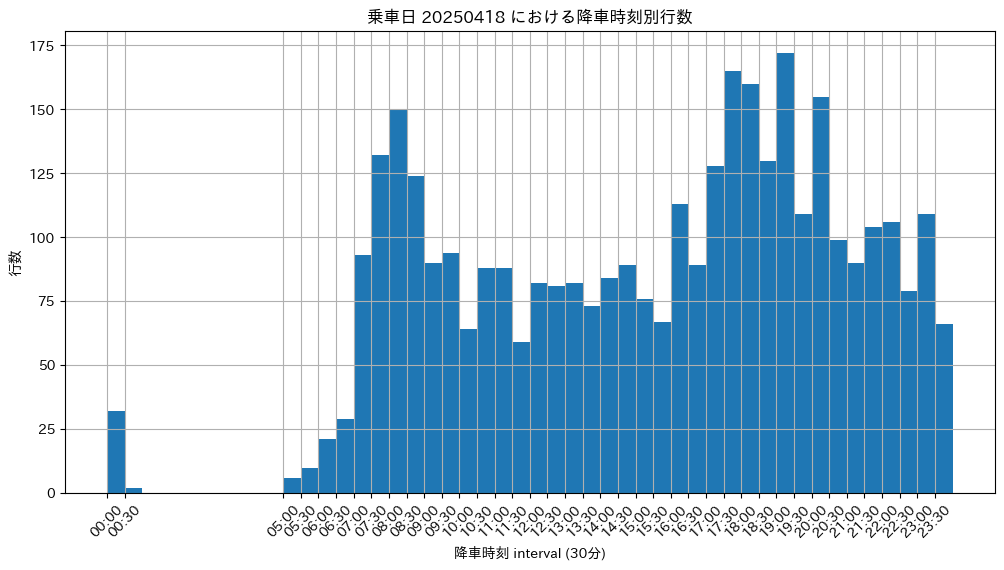

In [42]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250418
)

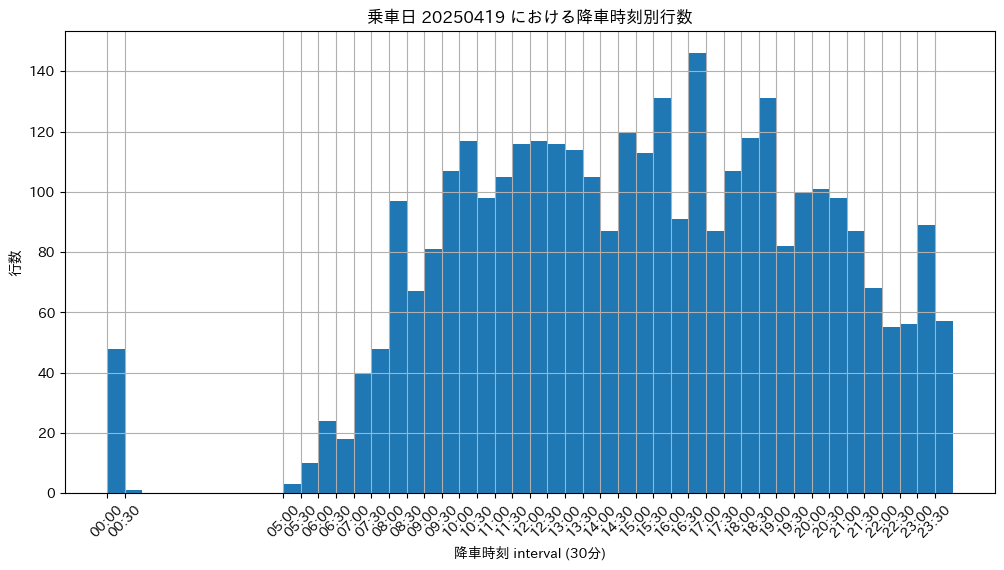

In [43]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250419
)

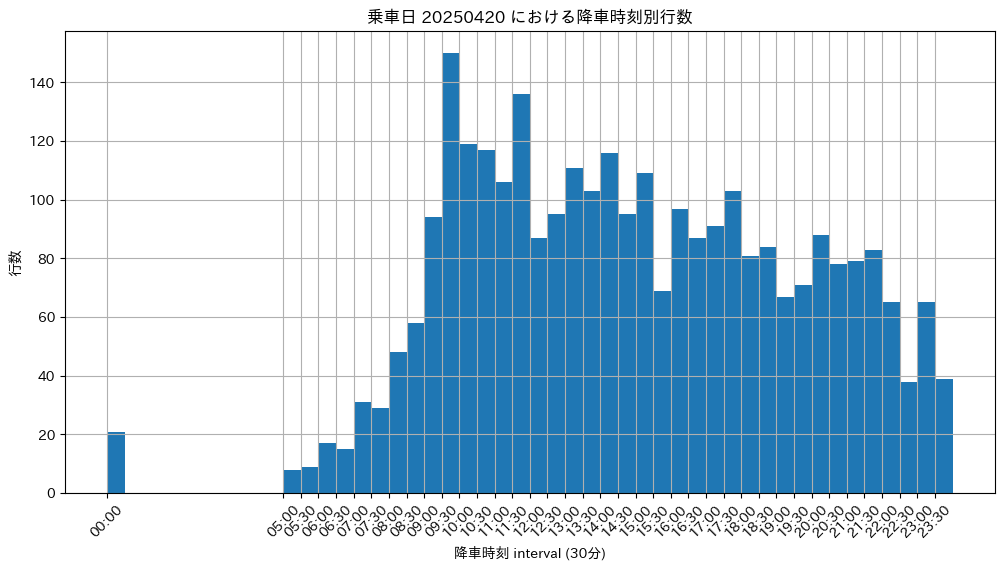

In [44]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250420
)

In [67]:
# 202507に対する抽出処理

# 20250707(Mon)~20250713(Sun)を抽出する
dates = (pl.col("乗車日") >= 20250707) & (pl.col("乗車日") <= 20250713)
df_filtered = df_202507.filter(dates)


# 降車駅：泉ケ丘駅を抽出する
izumigaoka = pl.col("降車駅") == "泉ケ丘"
df_filtered_izumigaoka = df_filtered.filter(izumigaoka)
# df_filtered_izumigaoka.head()


# 降車駅：鶴原駅を抽出する
turuhara = pl.col("降車駅") == "鶴原"
df_filtered_turuhara = df_filtered.filter(turuhara)
# df_filtered_turuhara.head()


# 降車駅：住吉大社駅を抽出する
sumiyoshi = pl.col("降車駅") == "住吉大社"
df_filtered_sumiyoshi = df_filtered.filter(sumiyoshi)
# df_filtered_sumiyoshi.head()

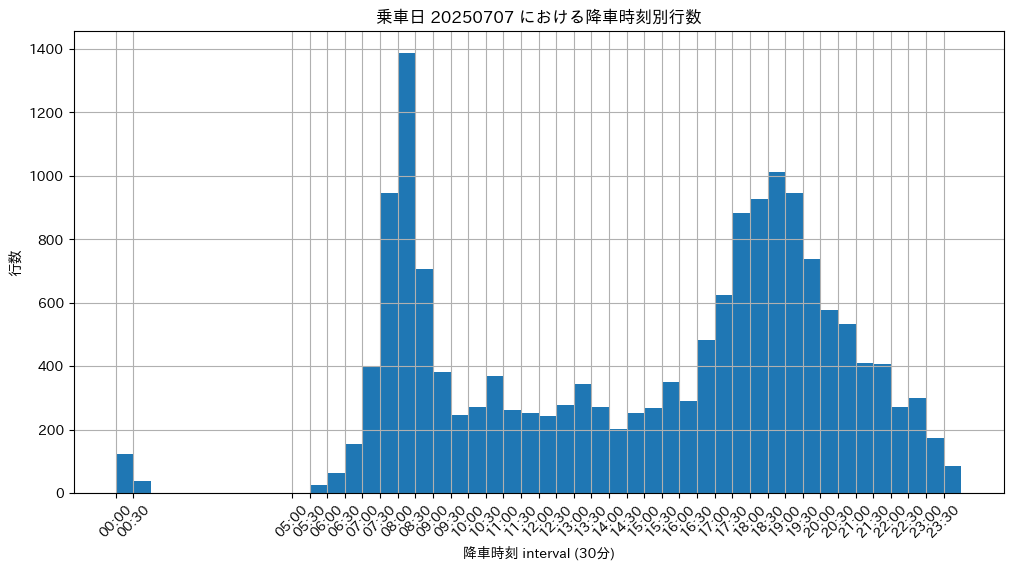

In [68]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250707
)

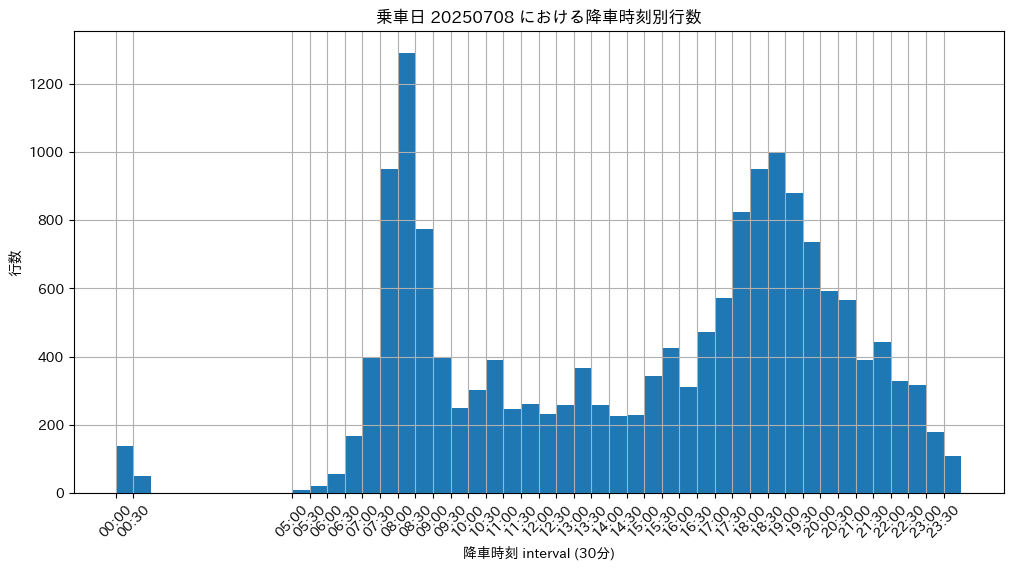

In [69]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250708
)

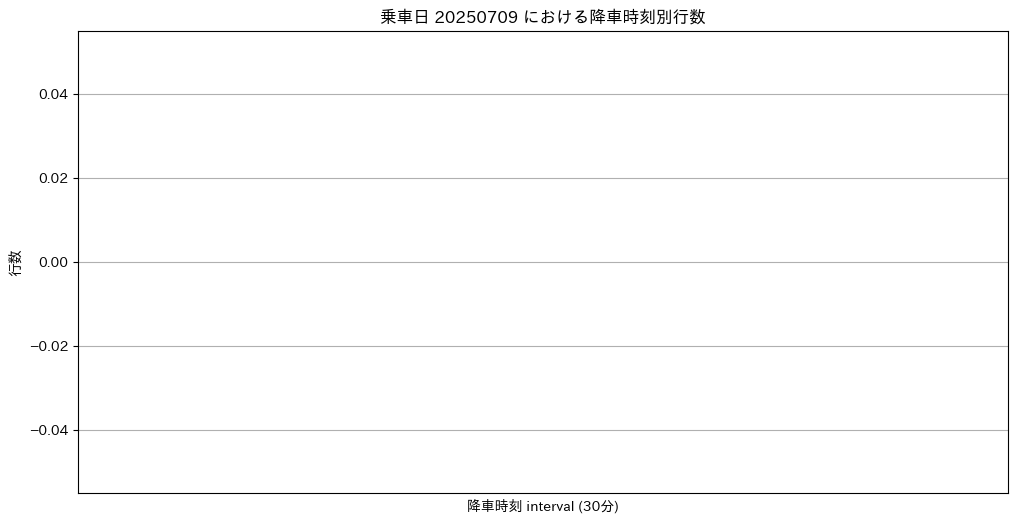

In [70]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250709
)

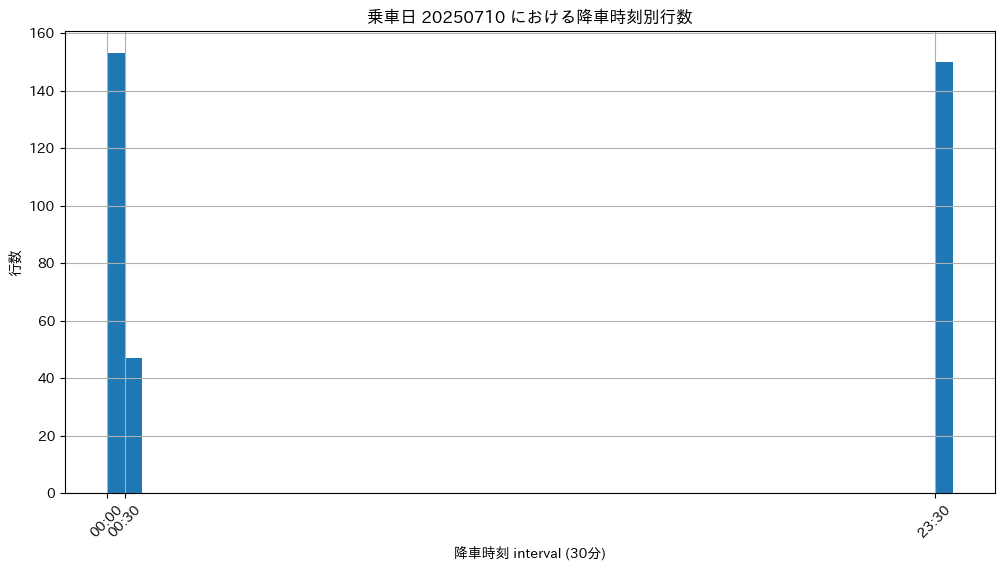

In [71]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250710
)

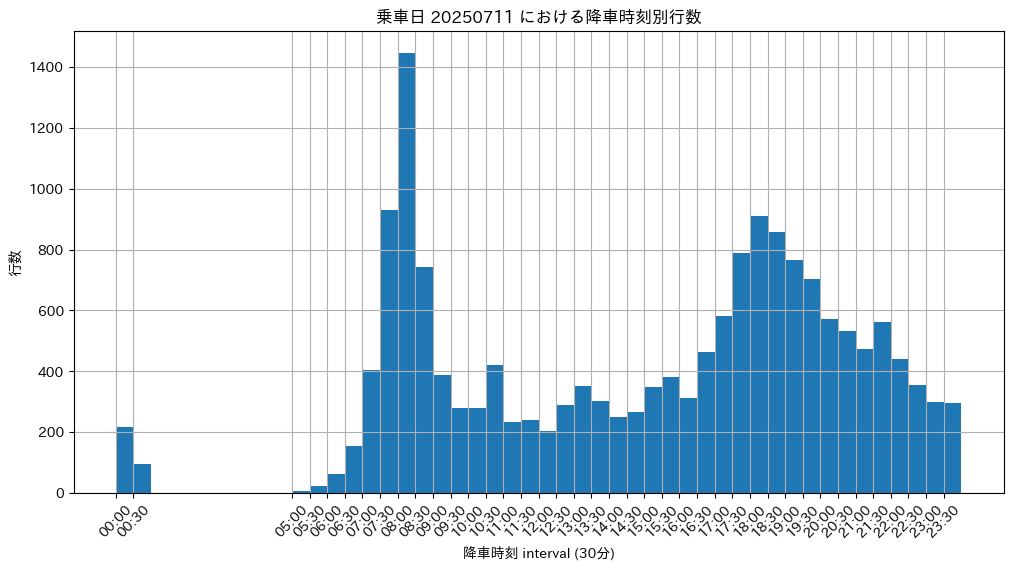

In [72]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250711
)

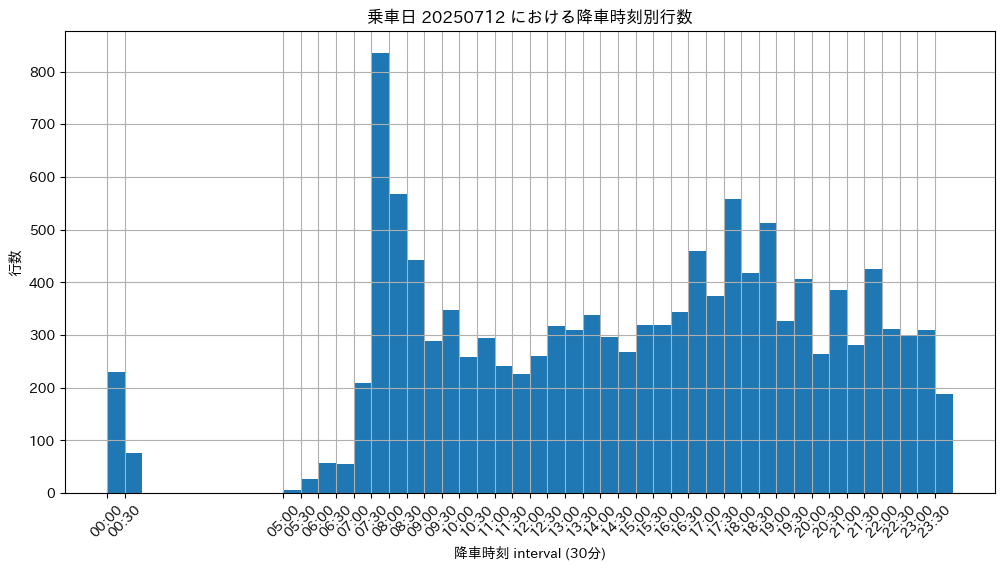

In [73]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250712
)

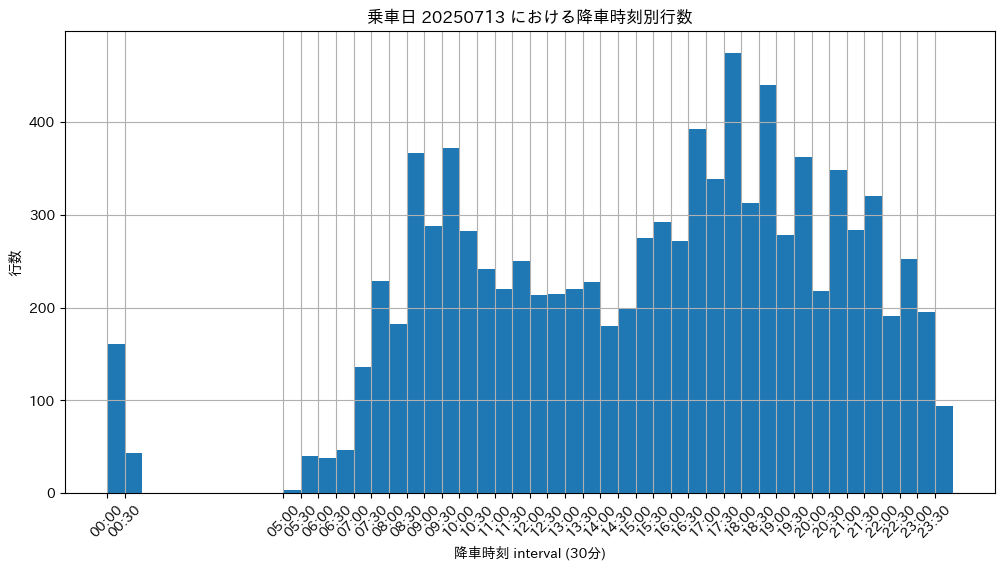

In [74]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20250713
)

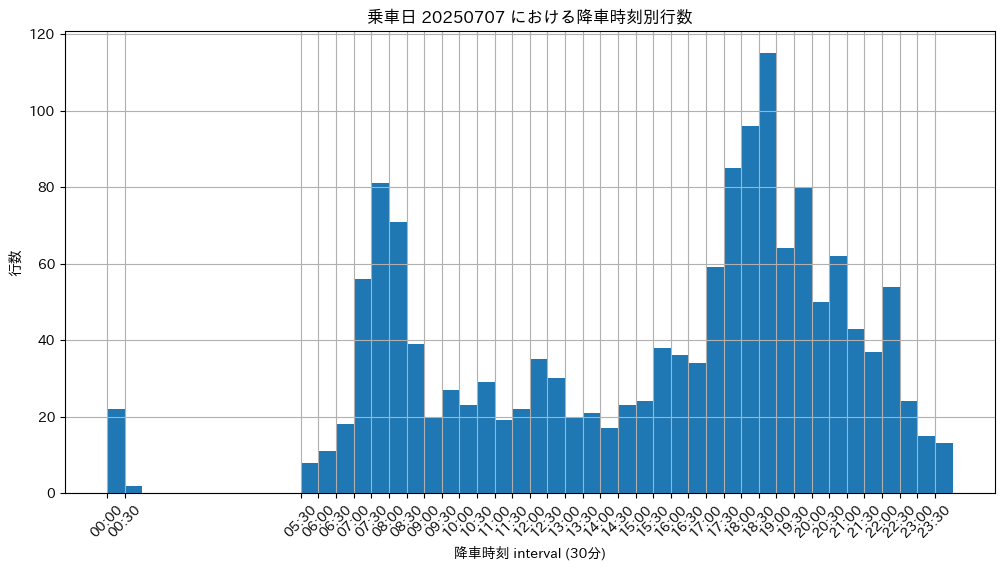

In [75]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250707
)

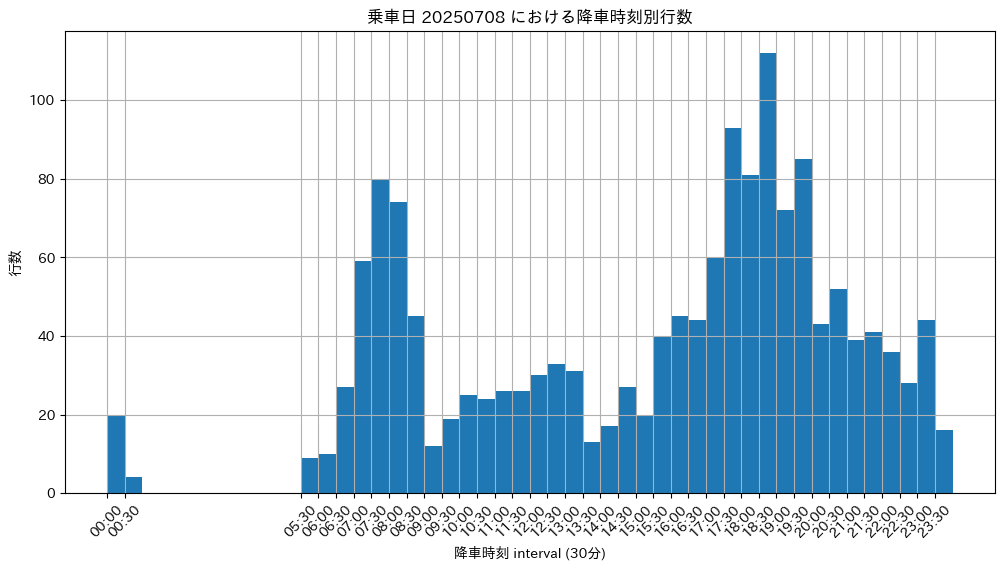

In [76]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250708
)

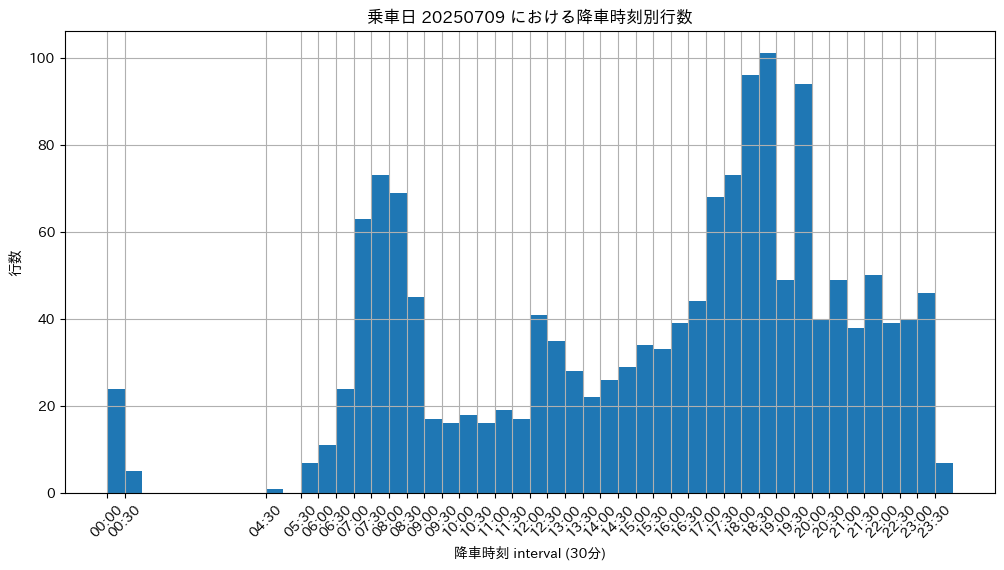

In [77]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250709
)

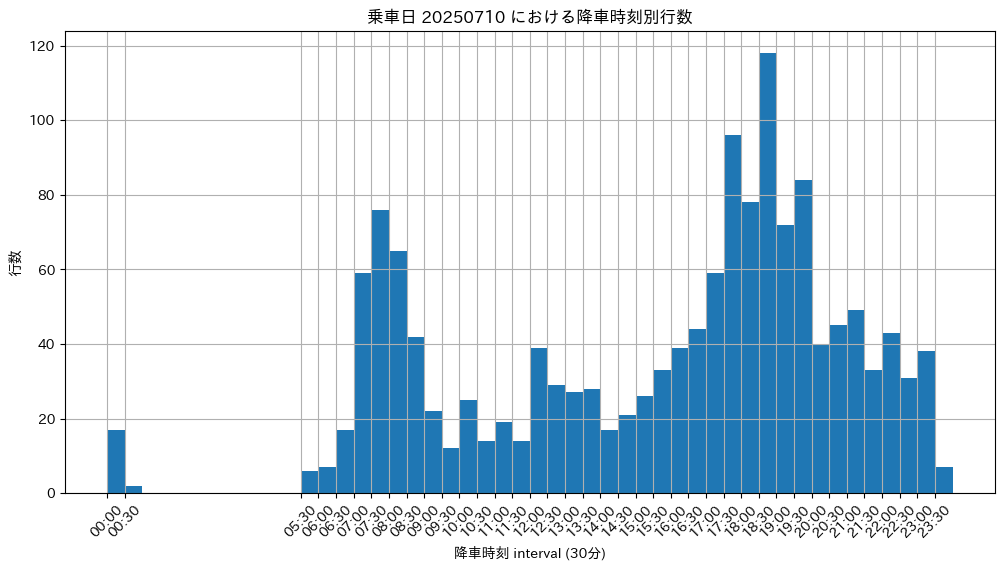

In [78]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250710
)

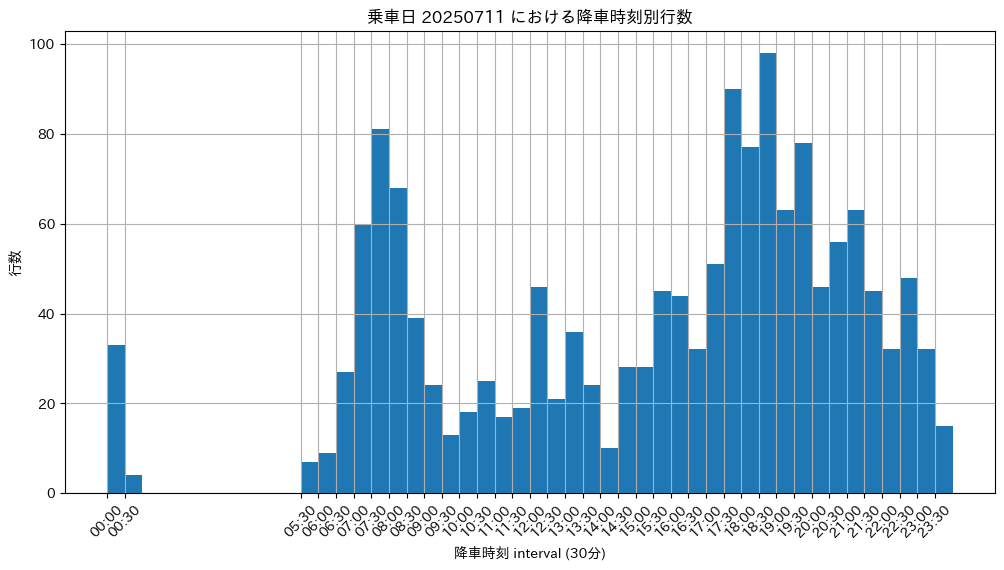

In [79]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250711
)

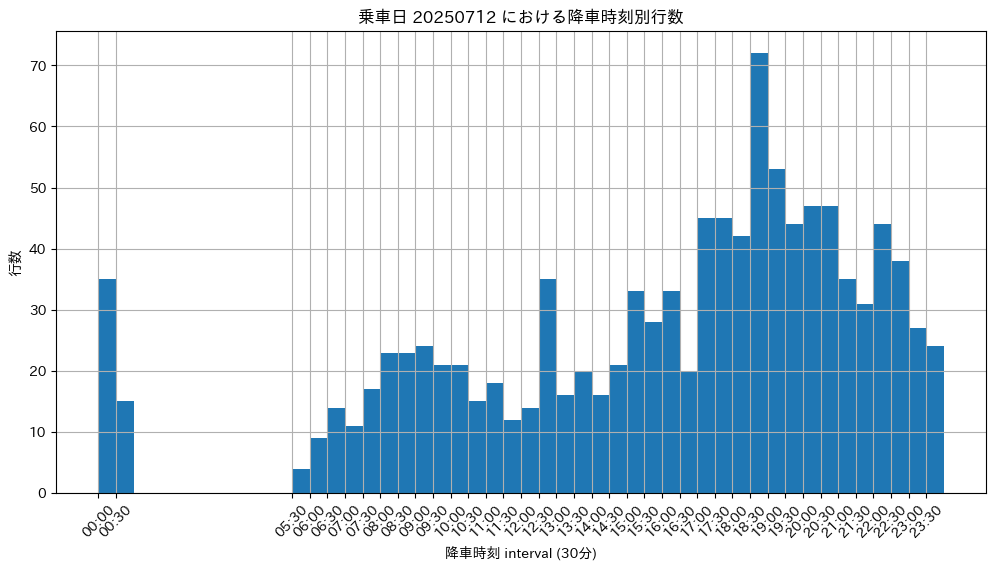

In [80]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250712
)

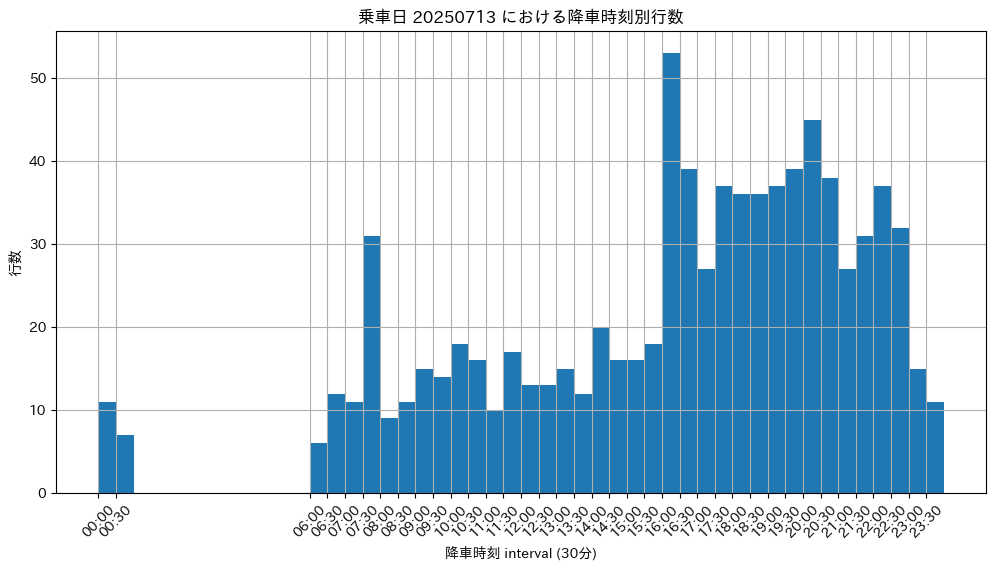

In [81]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20250713
)

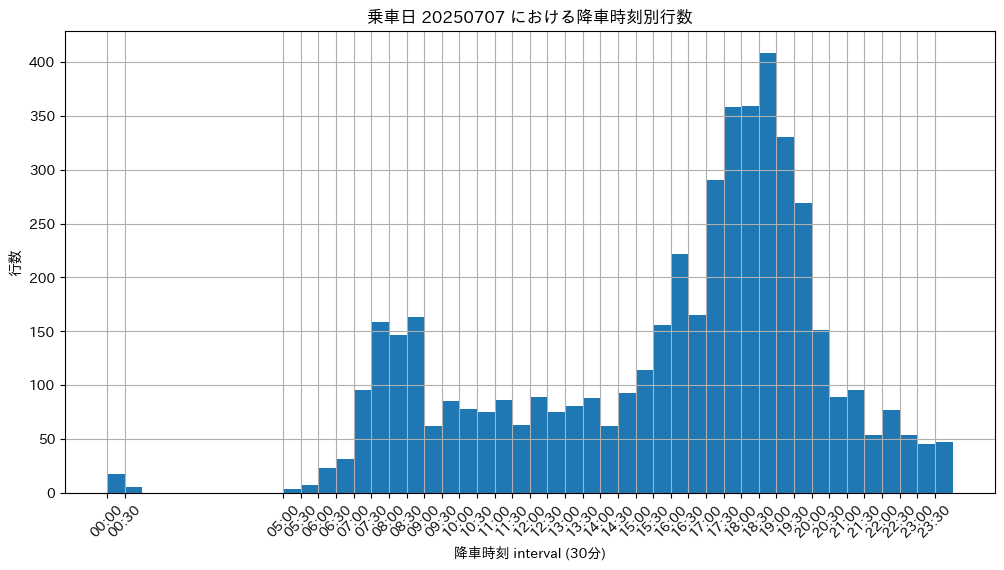

In [82]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250707
)

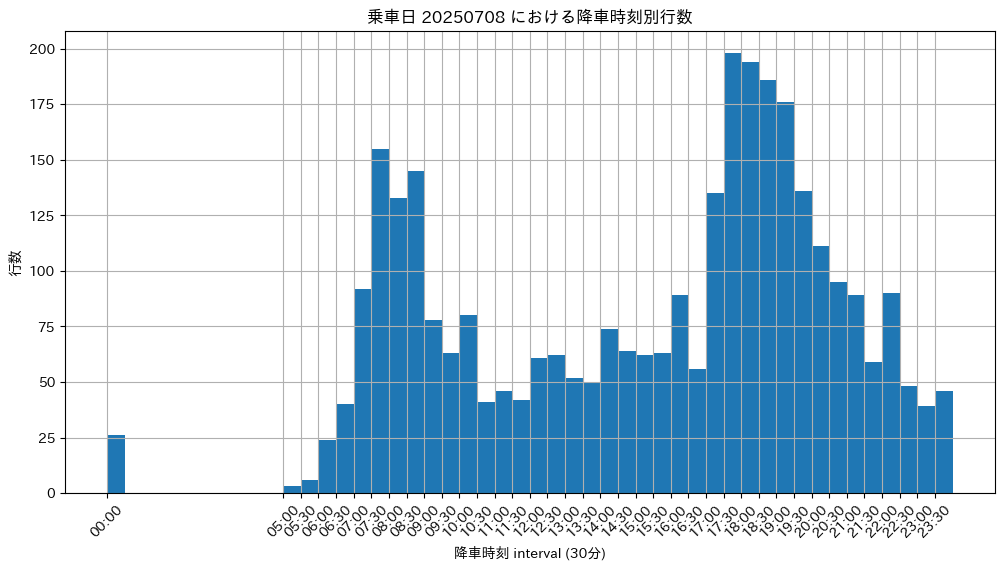

In [83]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250708
)

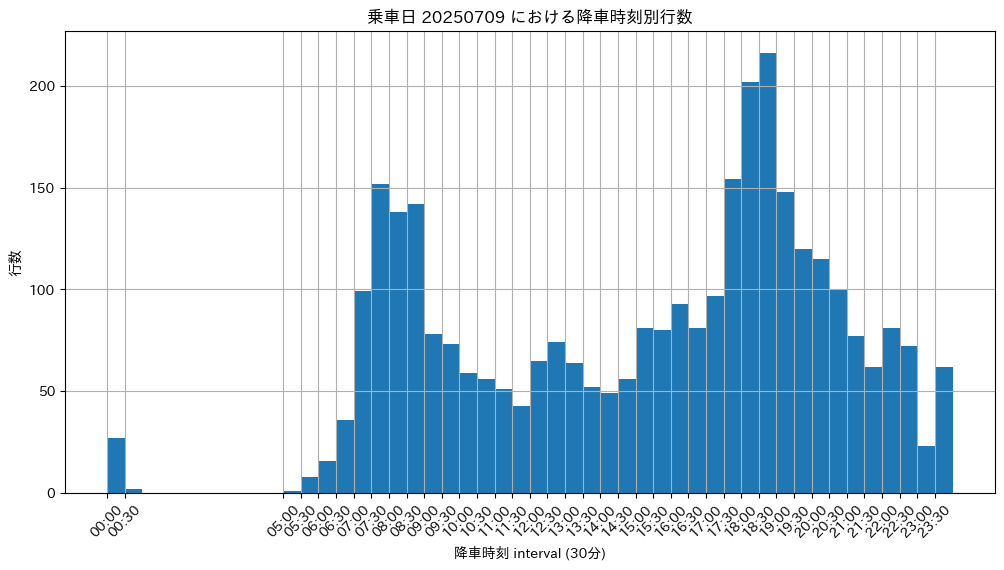

In [84]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250709
)

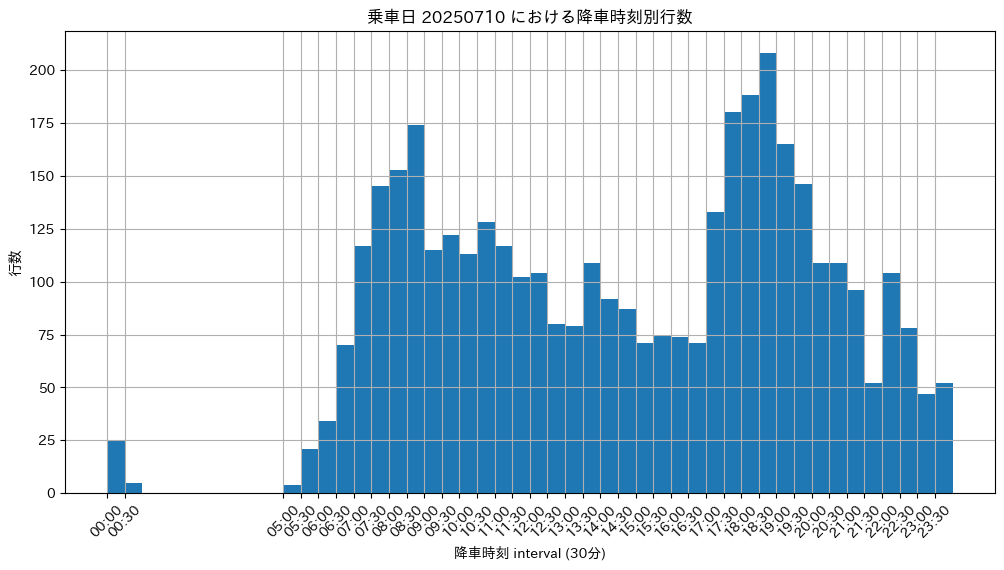

In [85]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250710
)

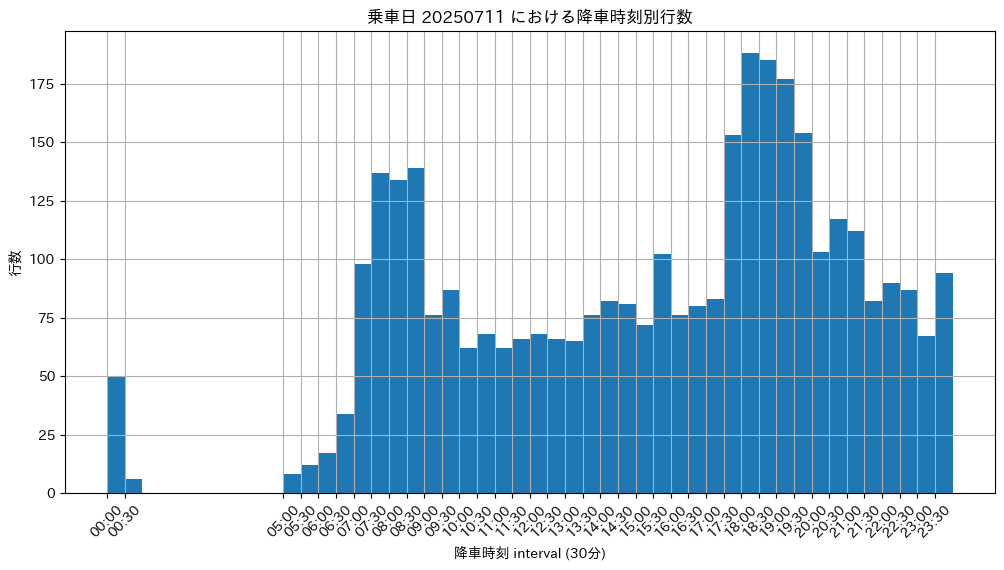

In [86]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250711
)

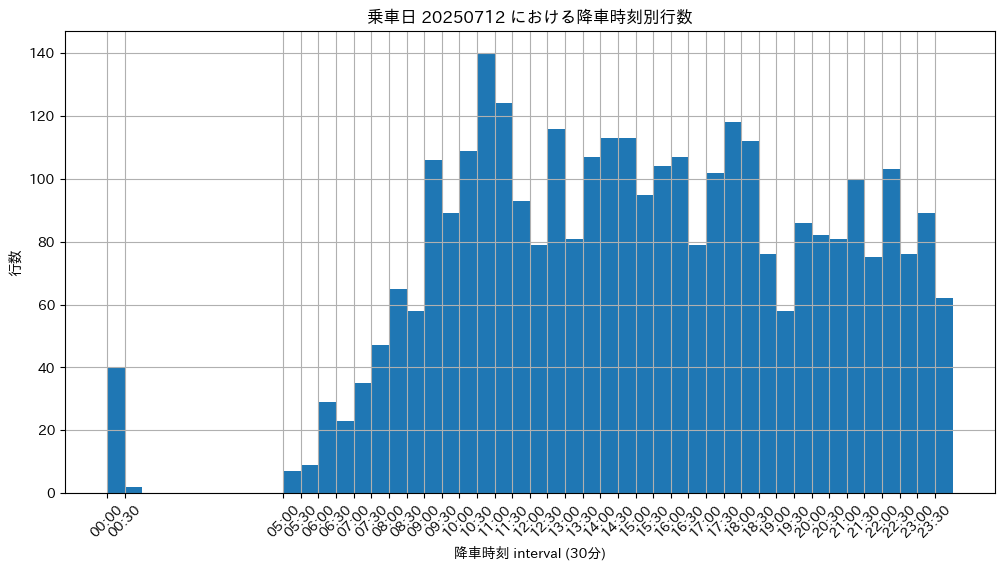

In [87]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250712
)

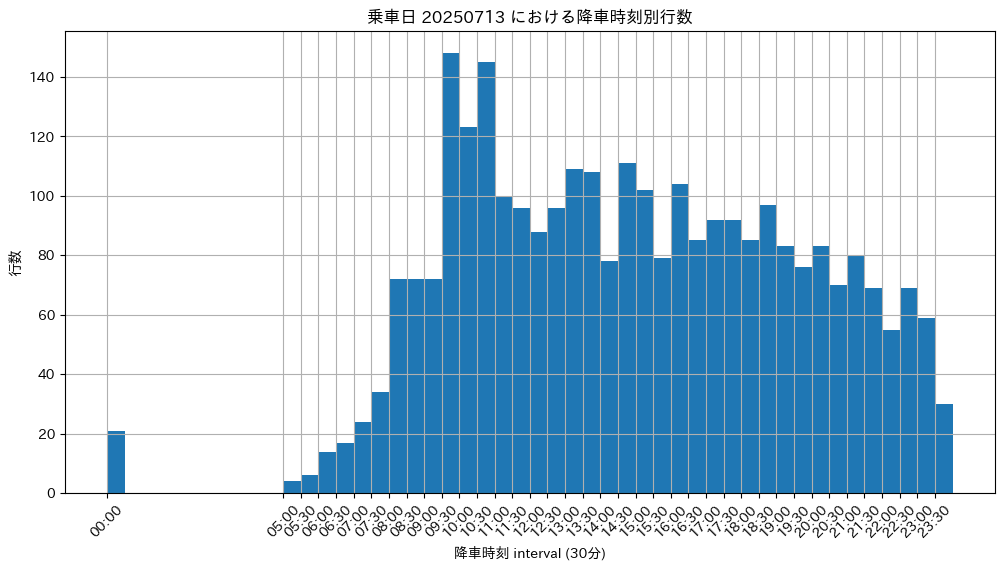

In [88]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20250713
)

In [89]:
# 202510に対する抽出処理

# 20251006(Mon)~20251012(Sun)を抽出する
dates = (pl.col("乗車日") >= 20251006) & (pl.col("乗車日") <= 20251012)
df_filtered = df_202510.filter(dates)


# 降車駅：泉ケ丘駅を抽出する
izumigaoka = pl.col("降車駅") == "泉ケ丘"
df_filtered_izumigaoka = df_filtered.filter(izumigaoka)
# df_filtered_izumigaoka.head()


# 降車駅：鶴原駅を抽出する
turuhara = pl.col("降車駅") == "鶴原"
df_filtered_turuhara = df_filtered.filter(turuhara)
# df_filtered_turuhara.head()


# 降車駅：住吉大社駅を抽出する
sumiyoshi = pl.col("降車駅") == "住吉大社"
df_filtered_sumiyoshi = df_filtered.filter(sumiyoshi)
# df_filtered_sumiyoshi.head()

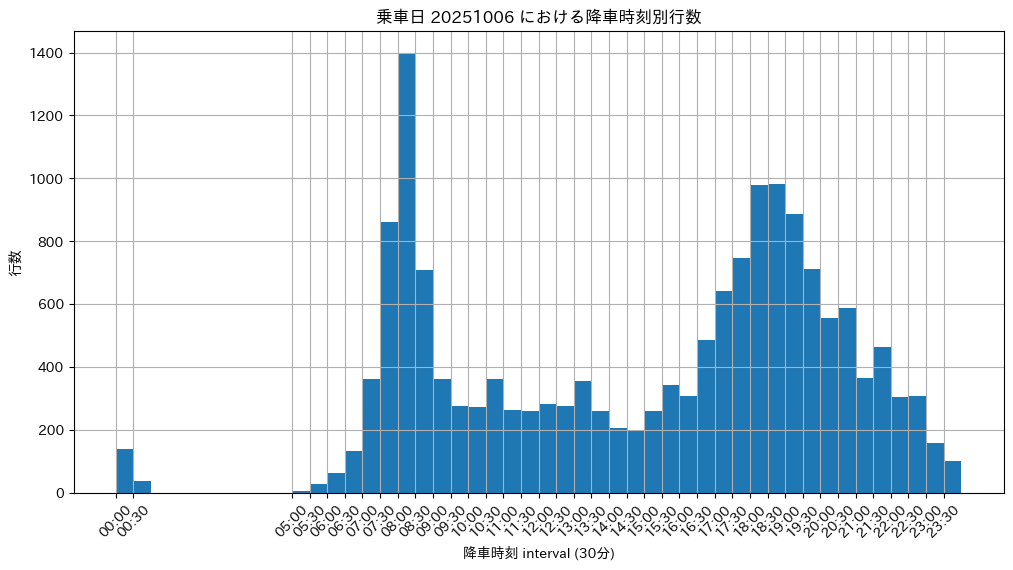

In [90]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20251006
)

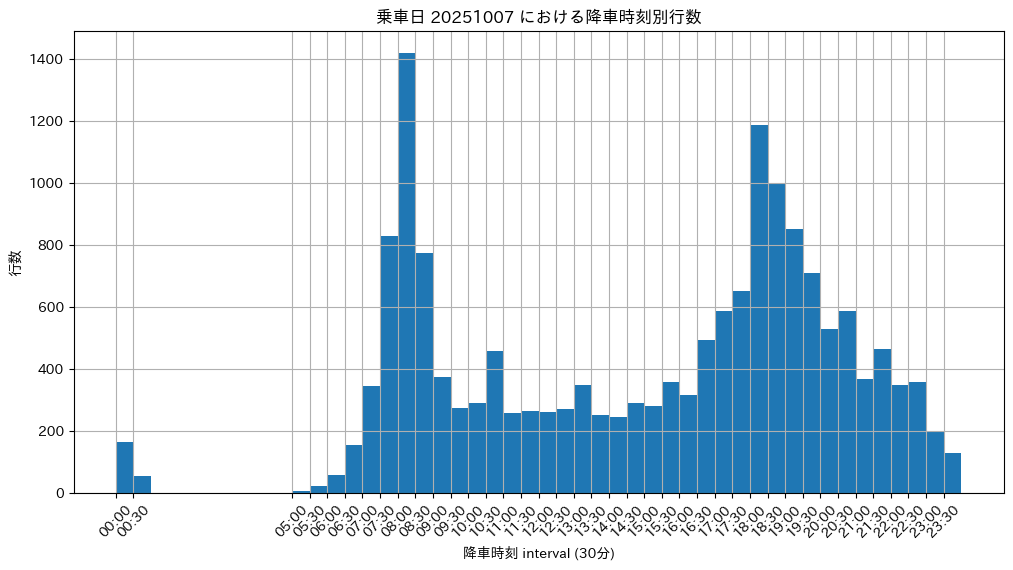

In [91]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20251007
)

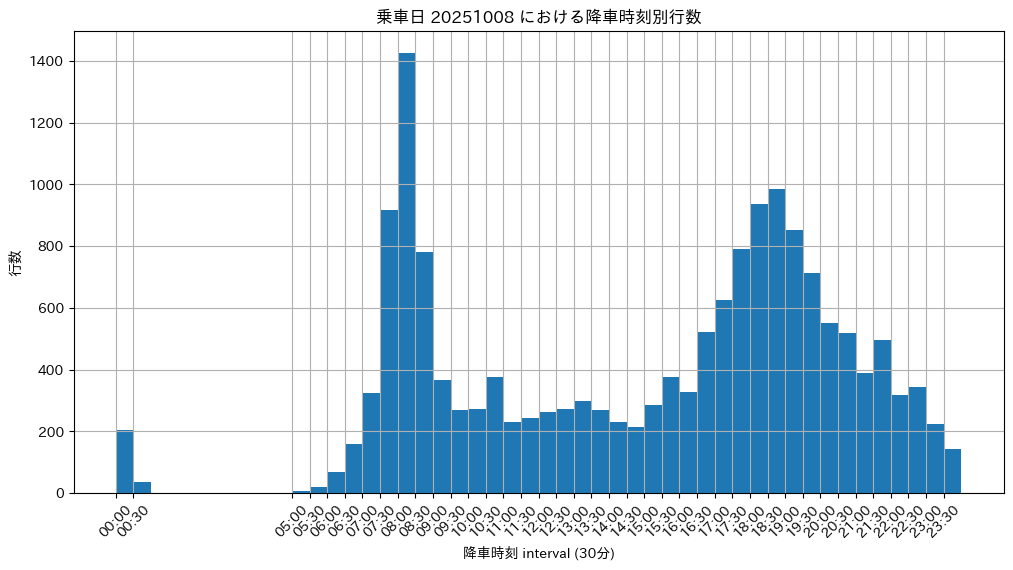

In [92]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20251008
)

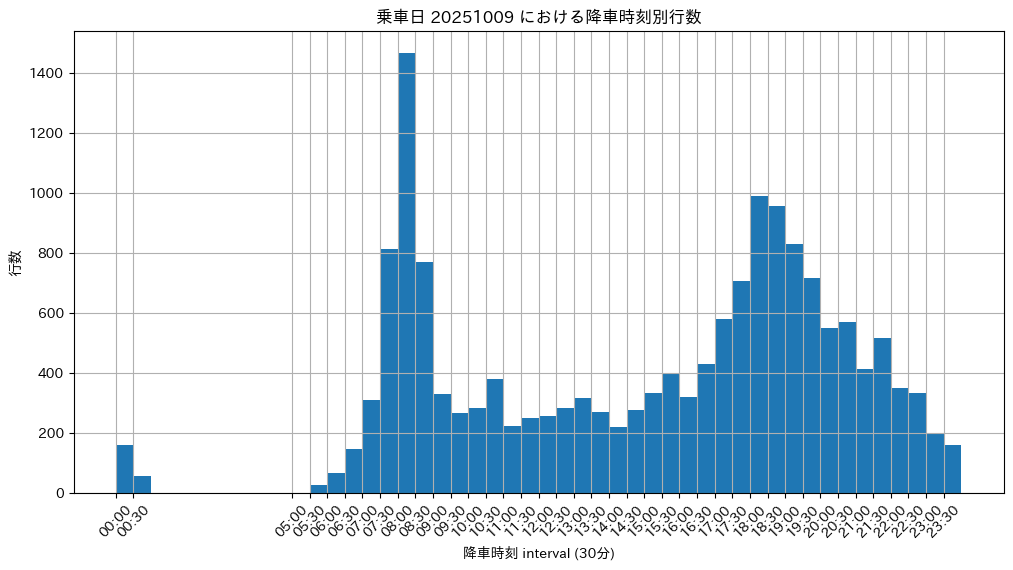

In [93]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20251009
)

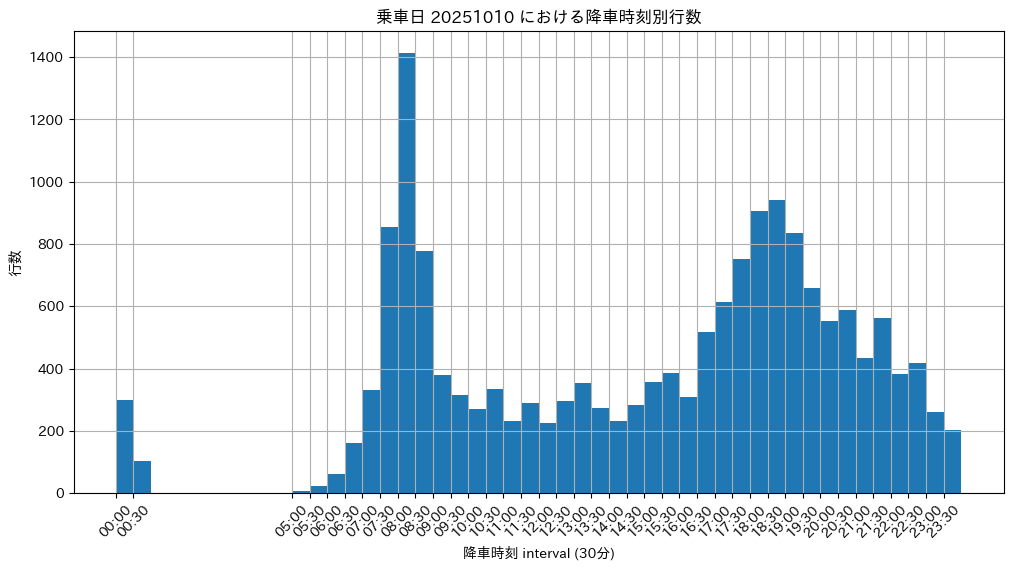

In [94]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20251010
)

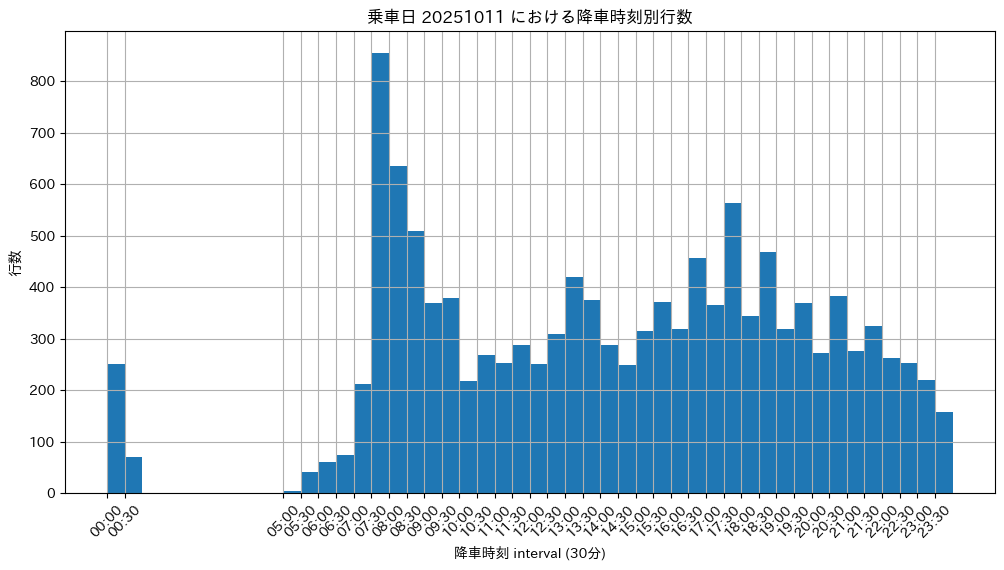

In [95]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20251011
)

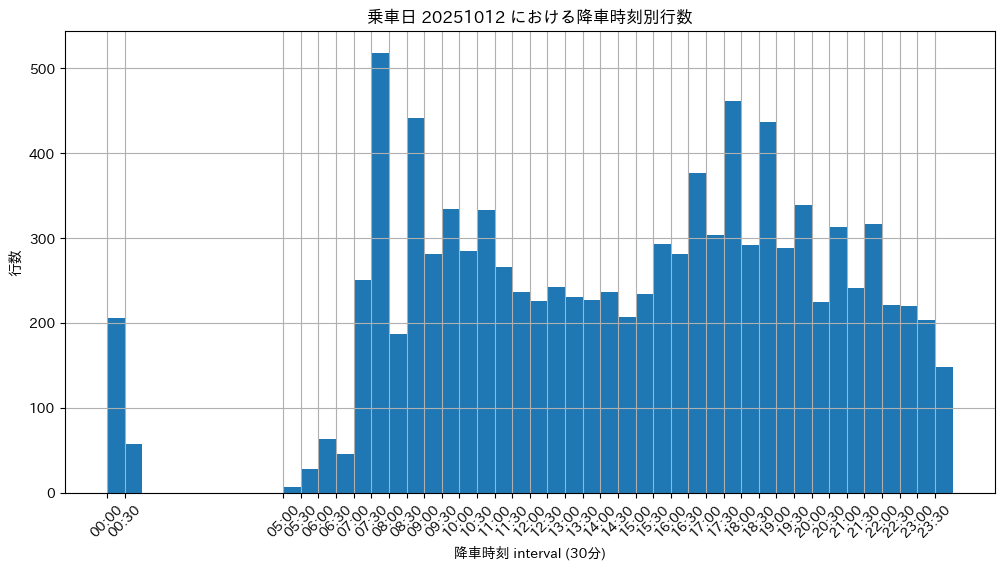

In [96]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20251012
)

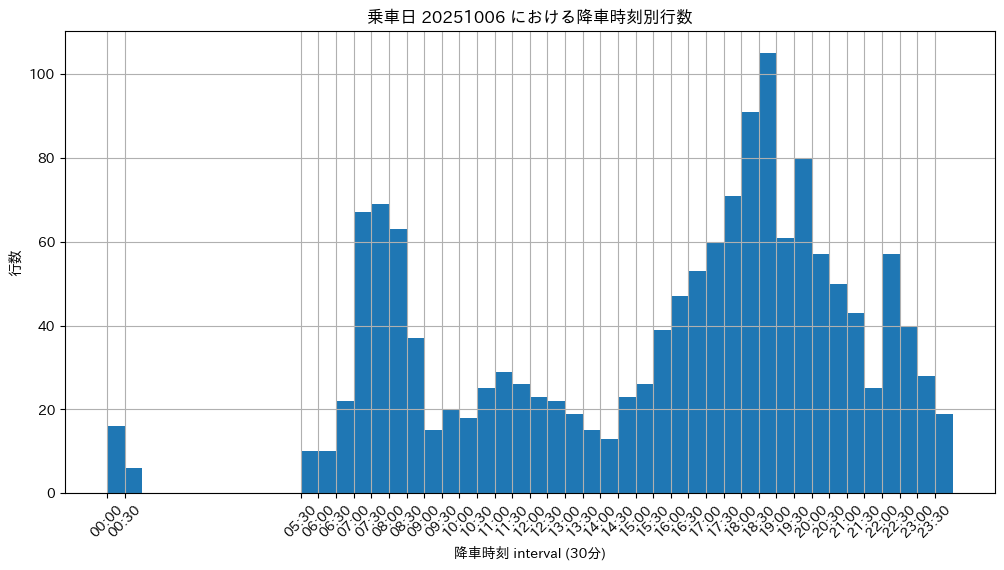

In [97]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20251006
)

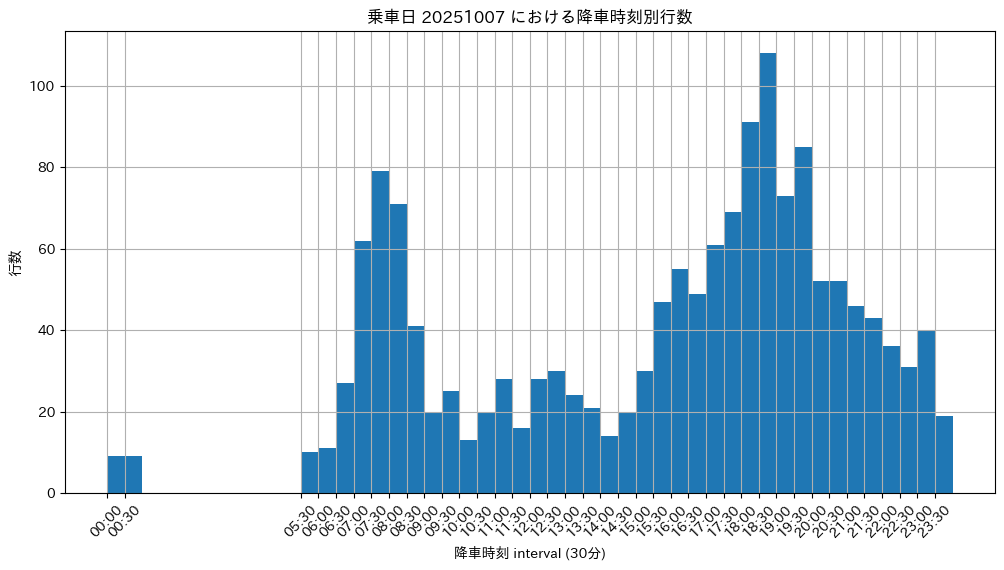

In [98]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20251007
)

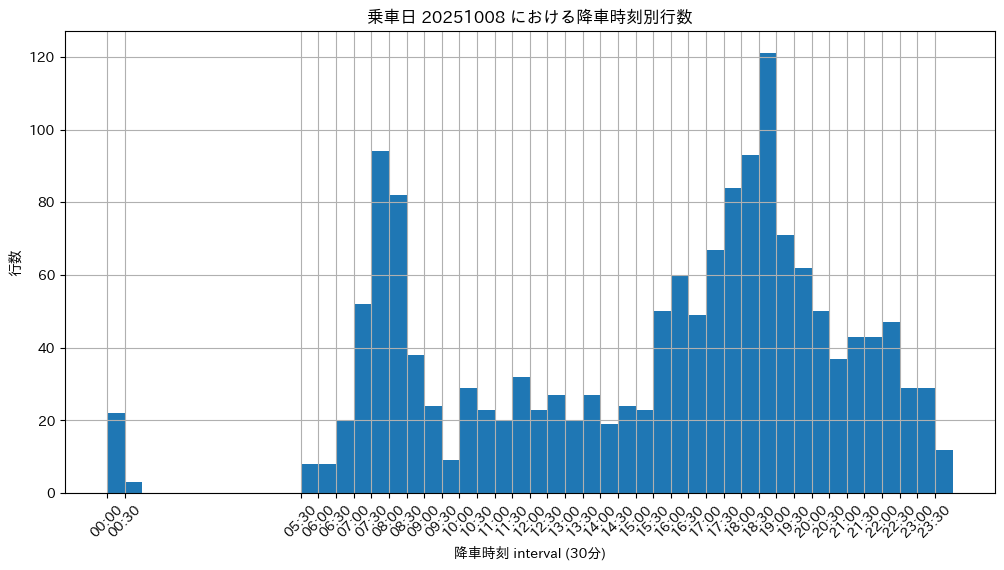

In [99]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20251008
)

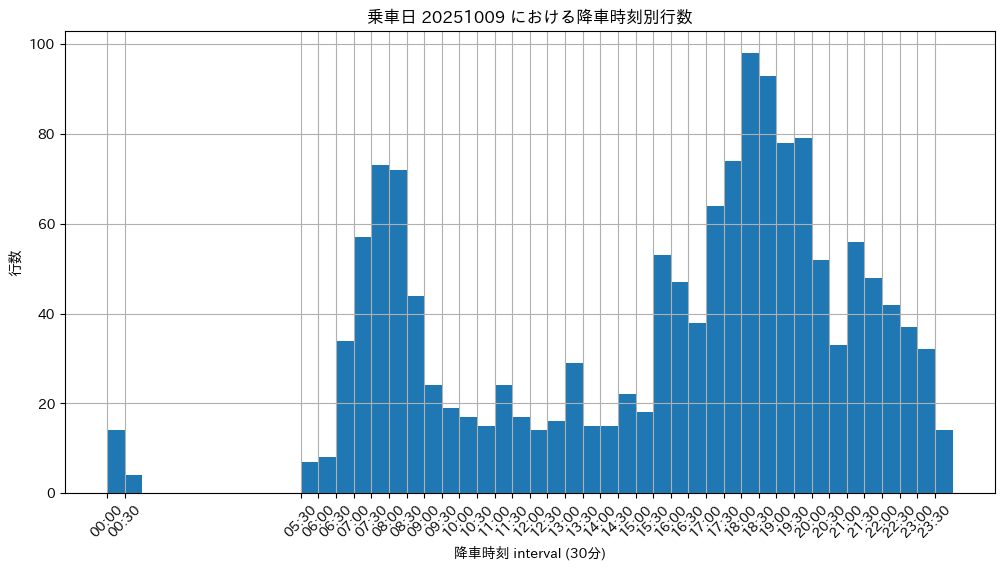

In [100]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20251009
)

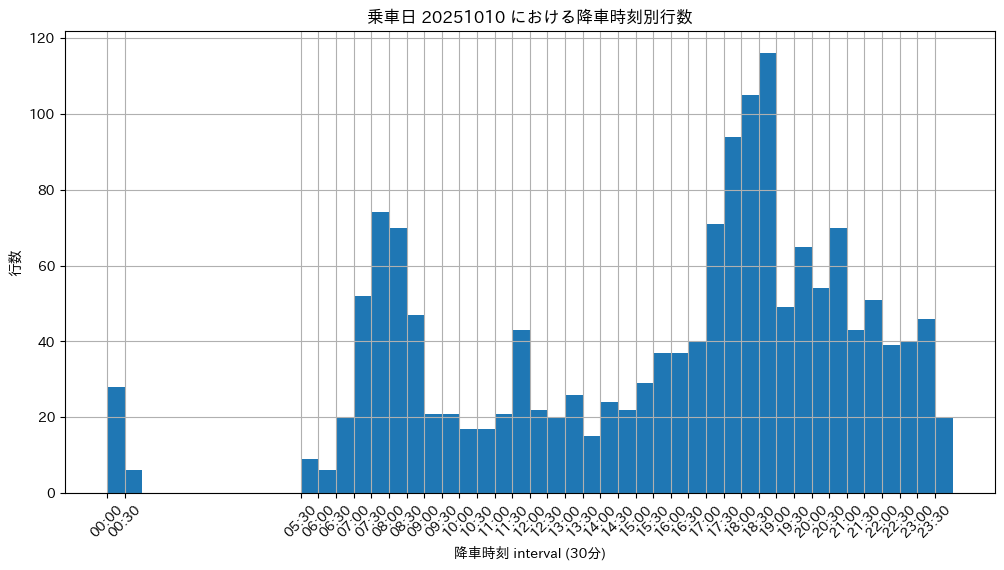

In [101]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20251010
)

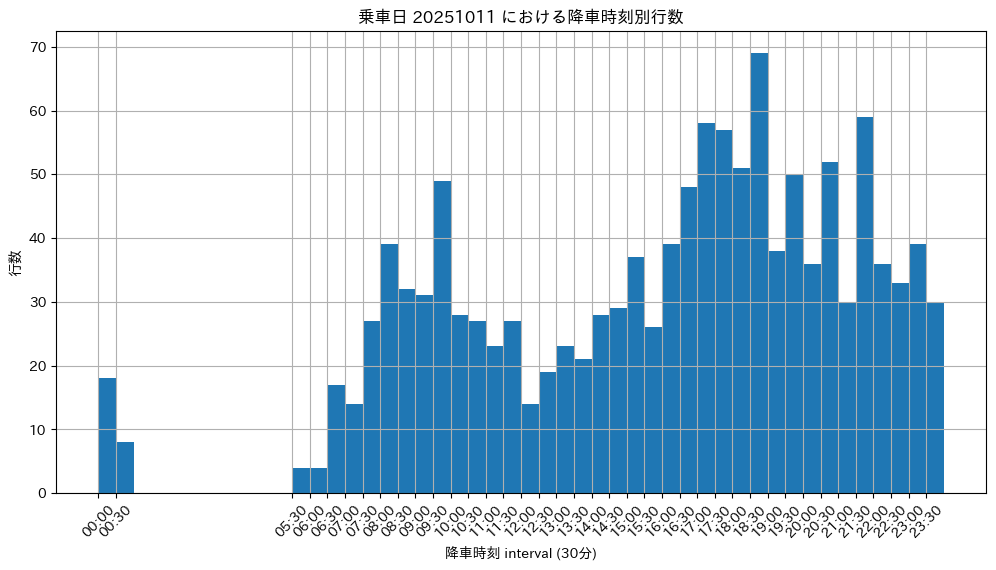

In [102]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20251011
)

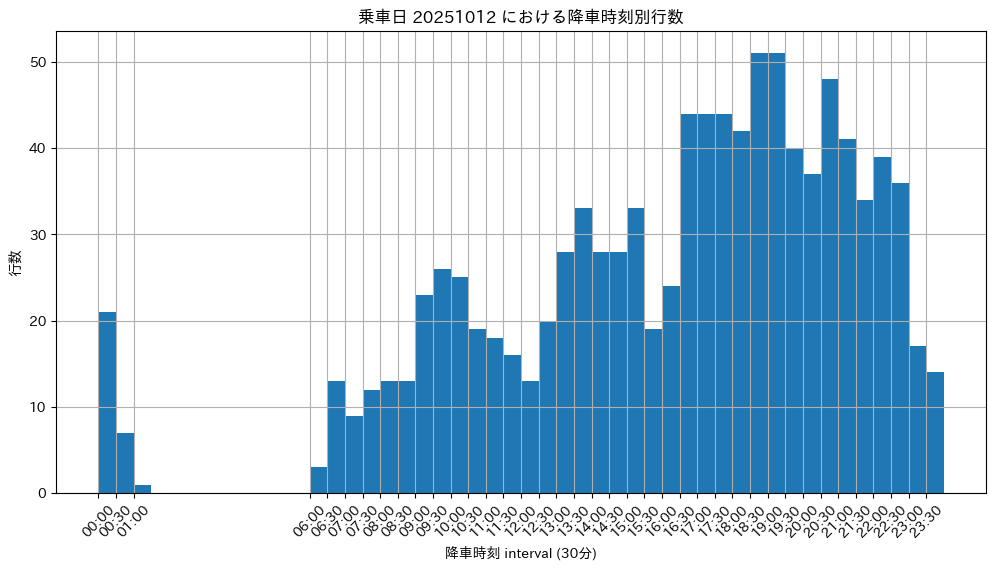

In [103]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20251012
)

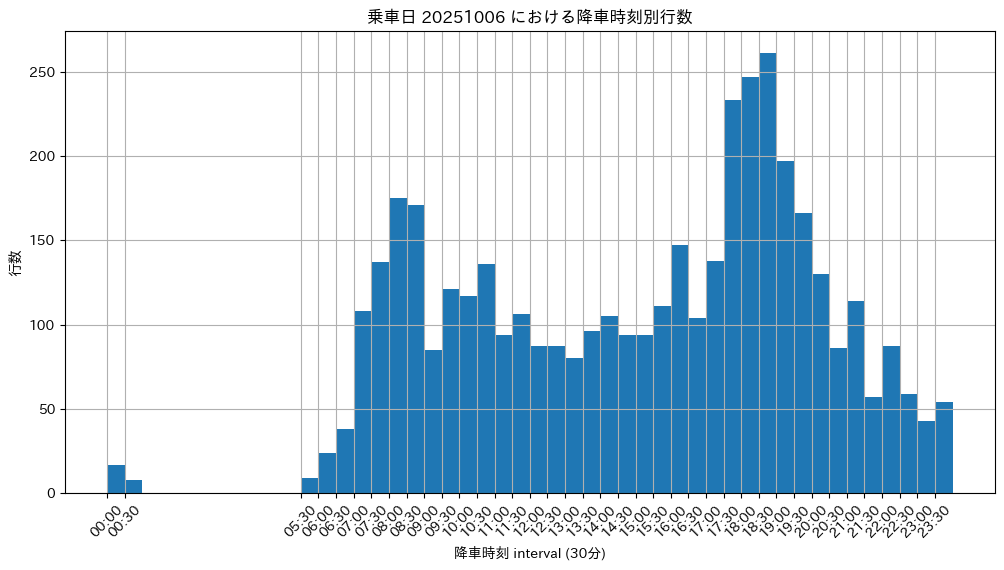

In [104]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20251006
)

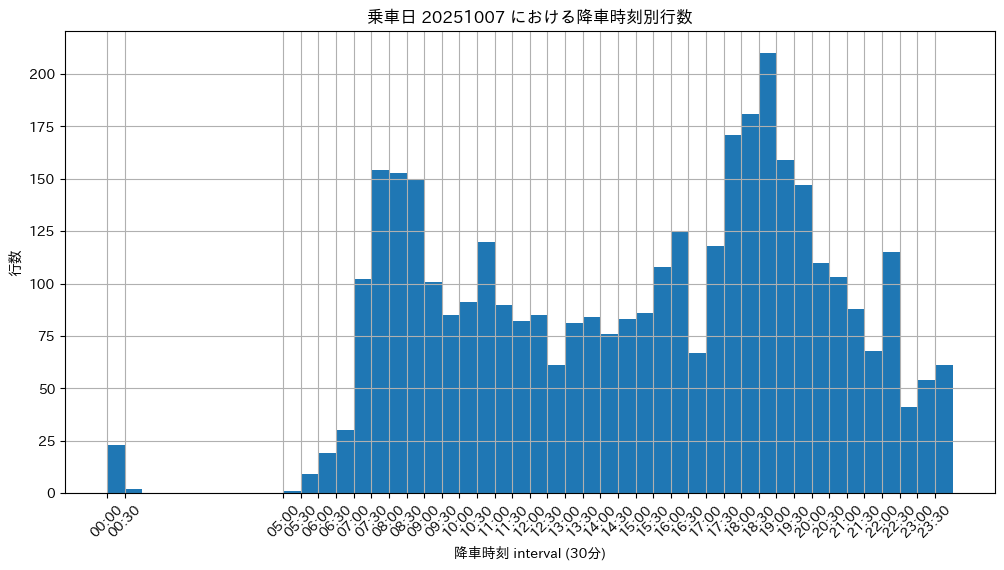

In [105]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20251007
)

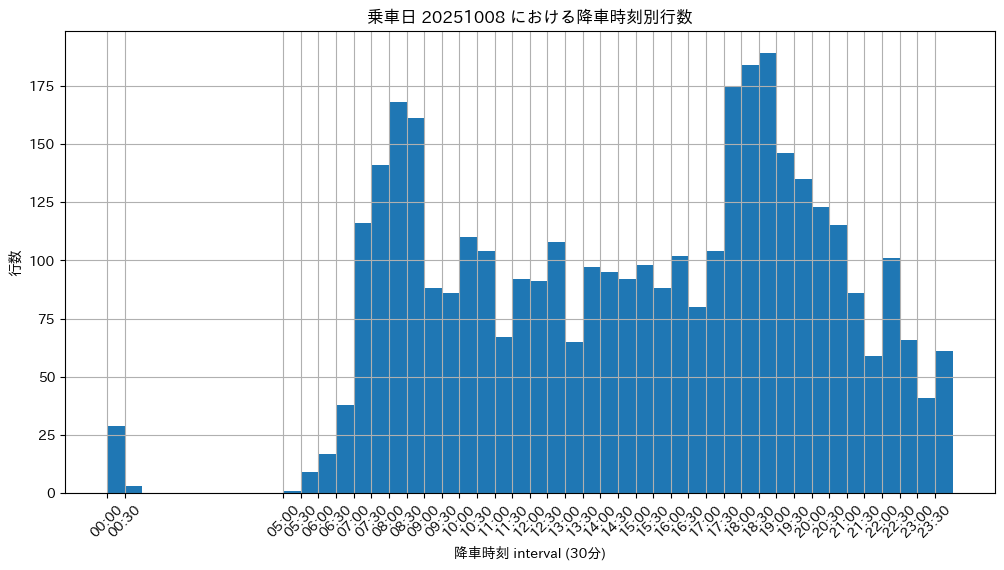

In [106]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20251008
)

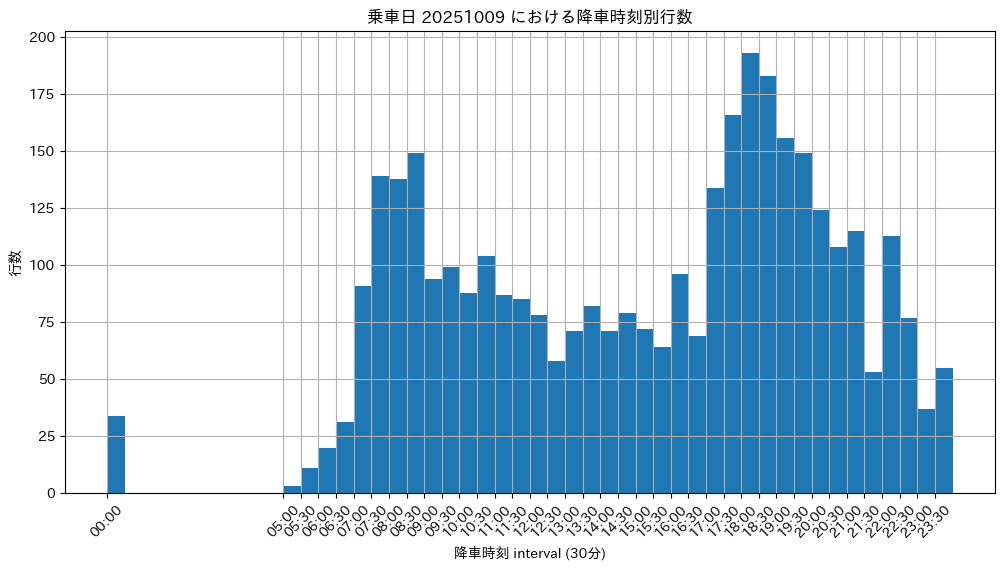

In [107]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20251009
)

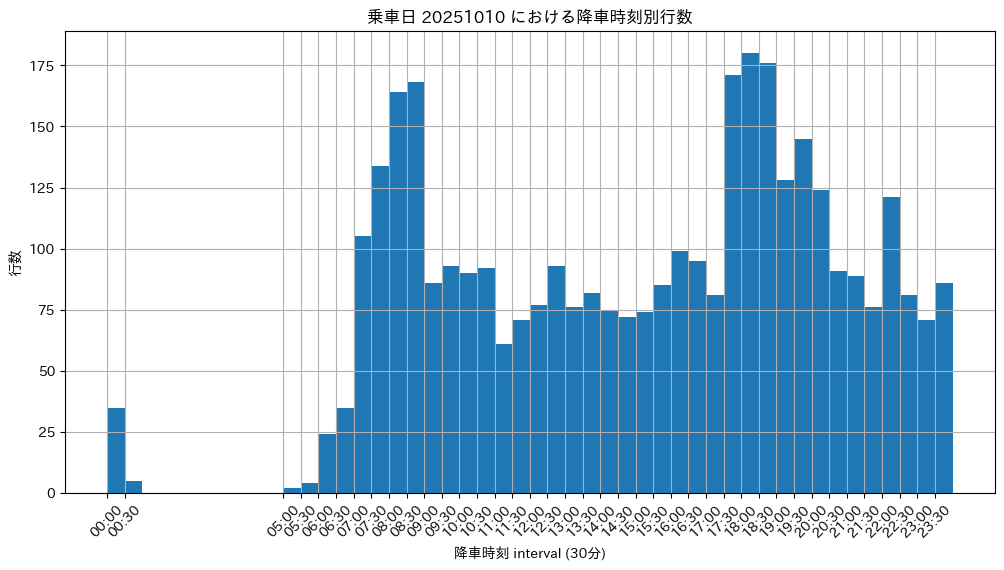

In [108]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20251010
)

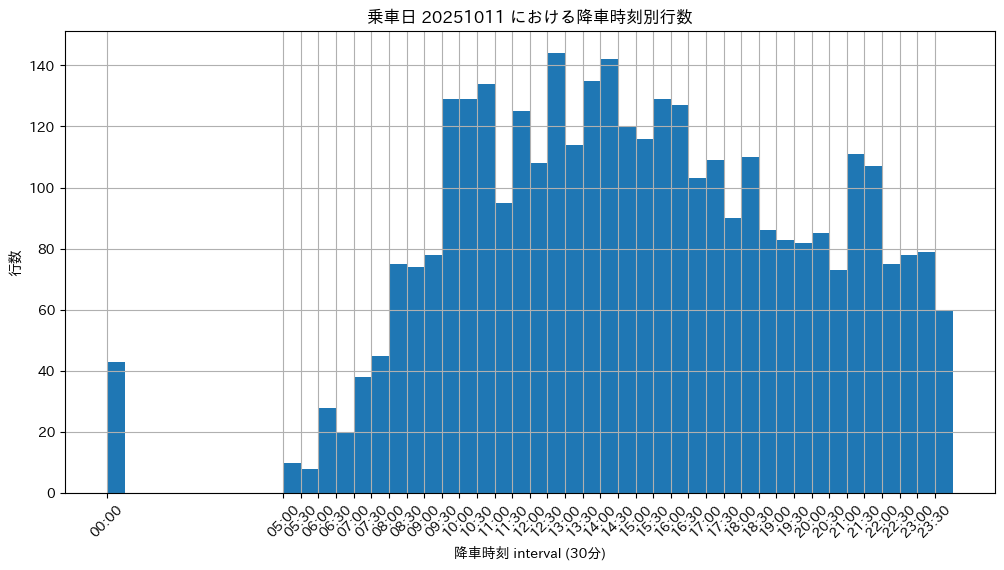

In [109]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20251011
)

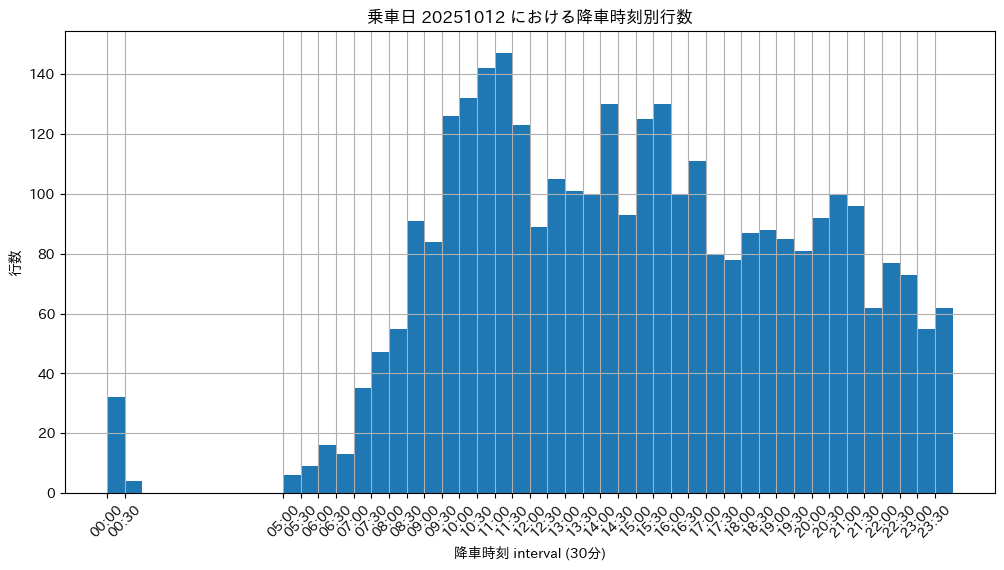

In [110]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20251012
)

In [111]:
# 202601に対する抽出処理

# 20260119(Mon)~20260125(Sun)を抽出する
dates = (pl.col("乗車日") >= 20260119) & (pl.col("乗車日") <= 20260125)
df_filtered = df_202601.filter(dates)


# 降車駅：泉ケ丘駅を抽出する
izumigaoka = pl.col("降車駅") == "泉ケ丘"
df_filtered_izumigaoka = df_filtered.filter(izumigaoka)
# df_filtered_izumigaoka.head()


# 降車駅：鶴原駅を抽出する
turuhara = pl.col("降車駅") == "鶴原"
df_filtered_turuhara = df_filtered.filter(turuhara)
# df_filtered_turuhara.head()


# 降車駅：住吉大社駅を抽出する
sumiyoshi = pl.col("降車駅") == "住吉大社"
df_filtered_sumiyoshi = df_filtered.filter(sumiyoshi)
# df_filtered_sumiyoshi.head()

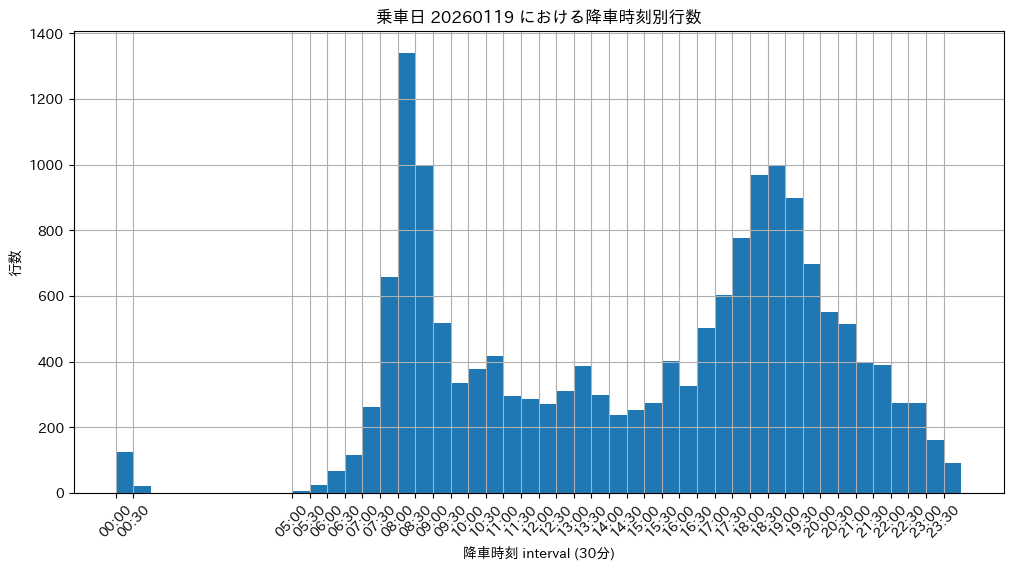

In [112]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20260119
)

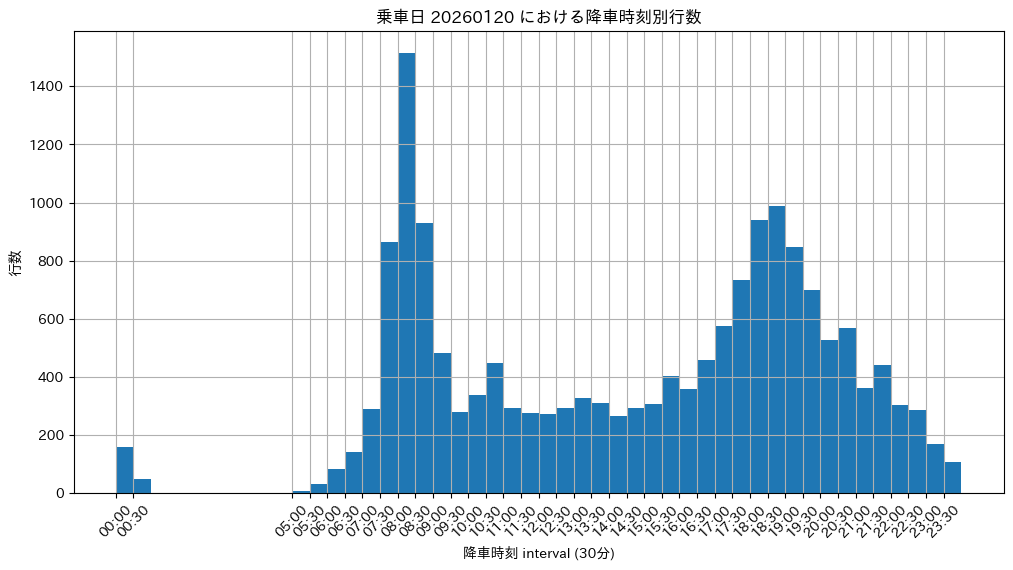

In [113]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20260120
)

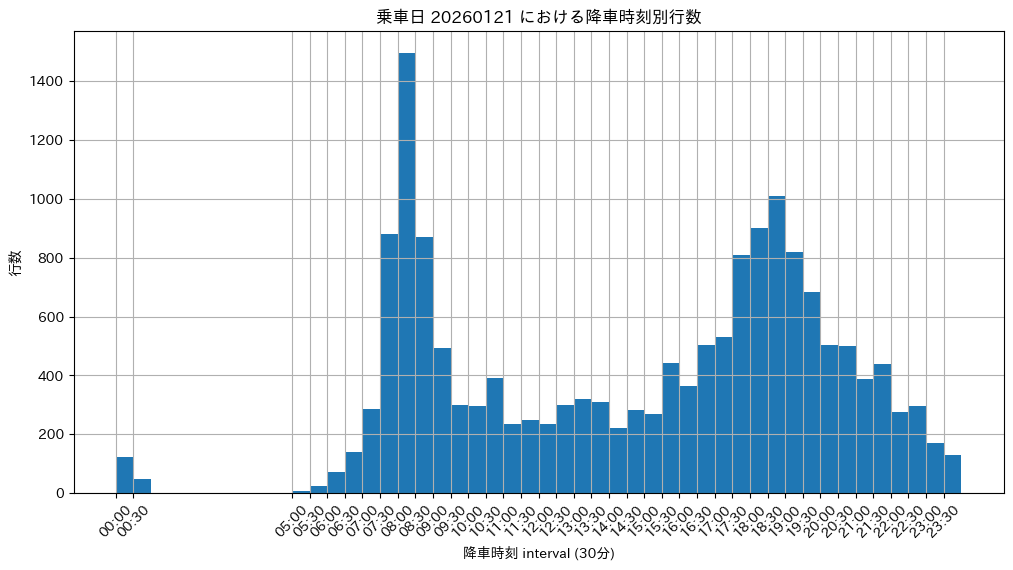

In [114]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20260121
)

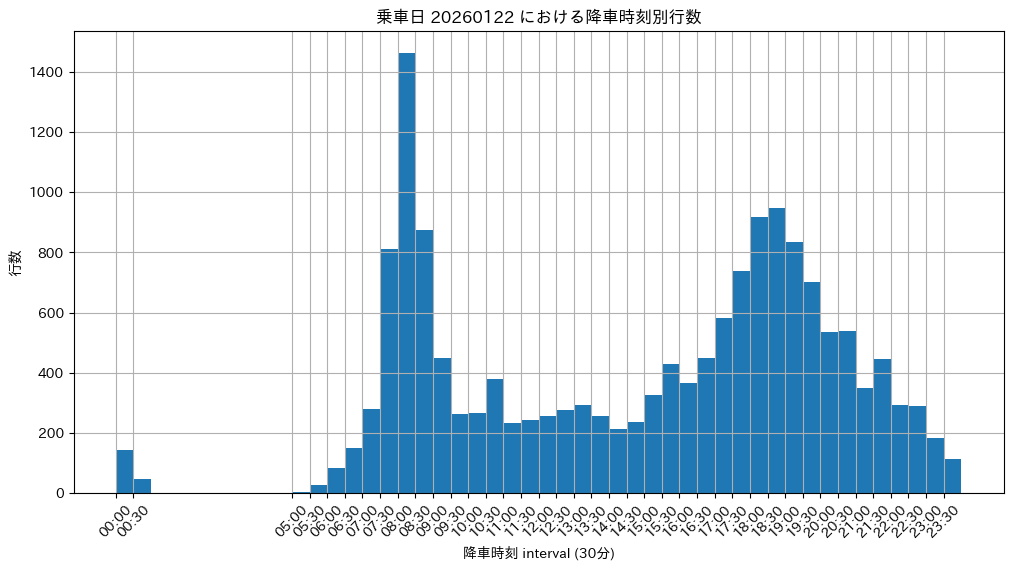

In [115]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20260122
)

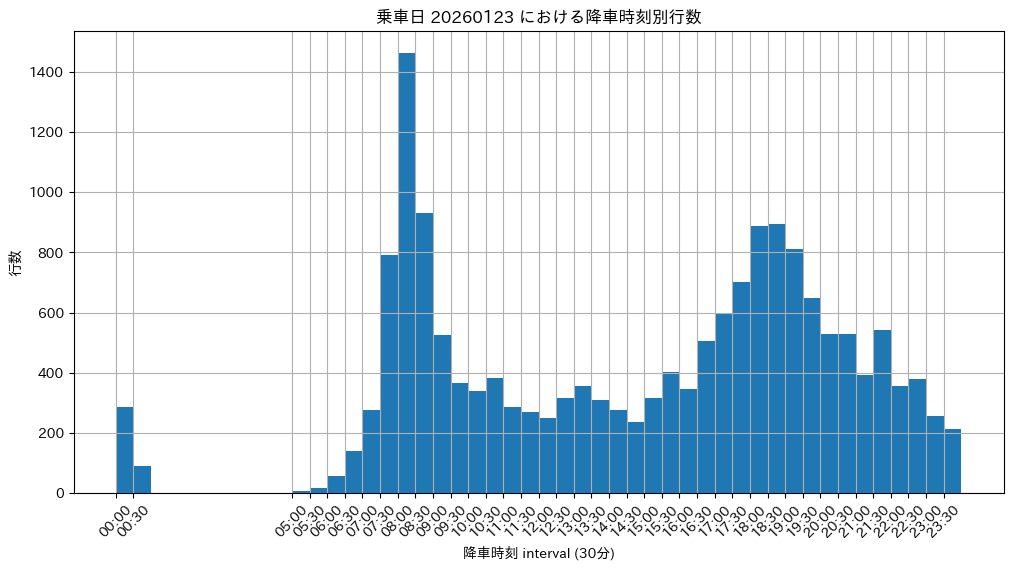

In [116]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20260123
)

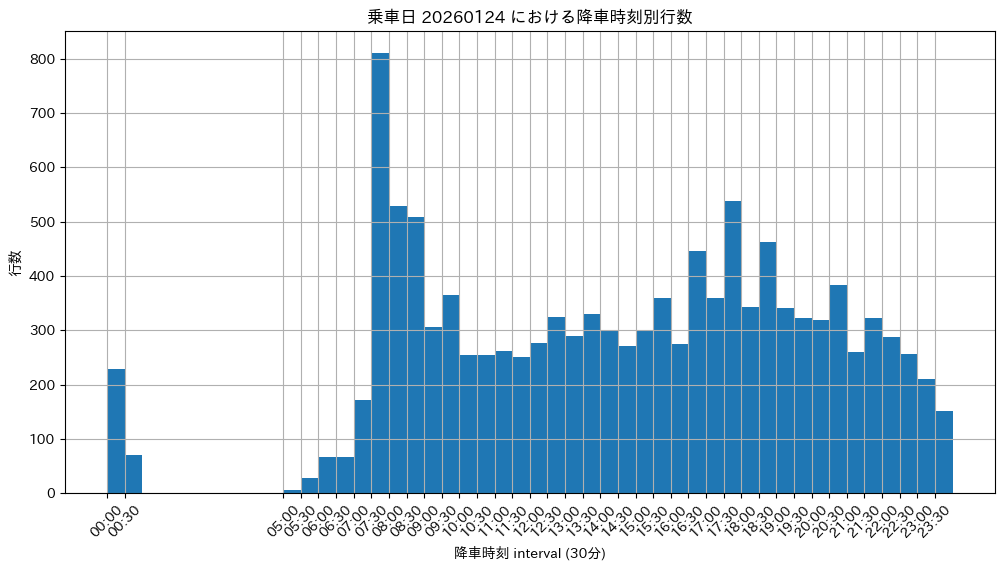

In [117]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20260124
)

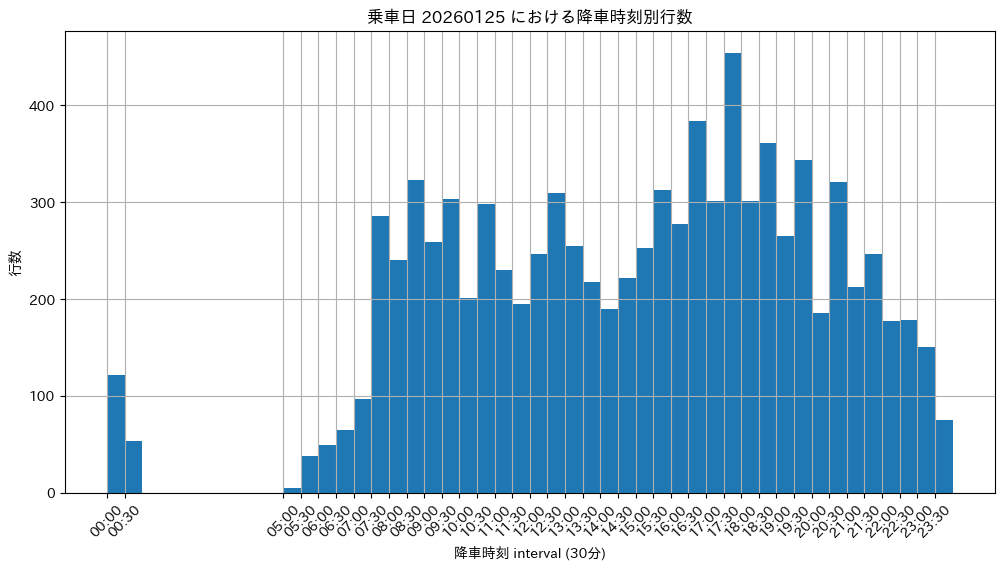

In [118]:
plot_dropoff_count_by_time(
    df = df_filtered_izumigaoka,
    target_date=20260125
)

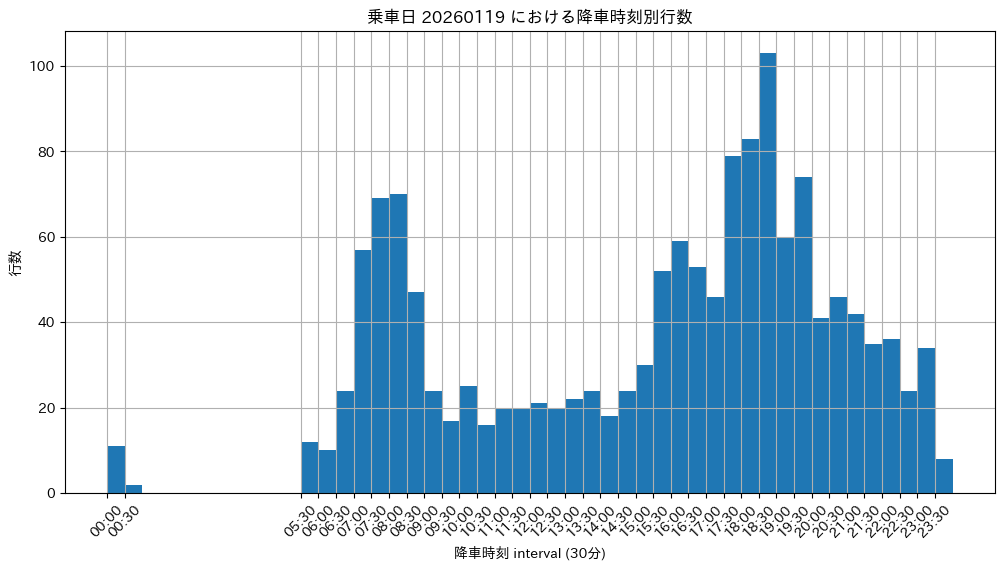

In [119]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20260119
)

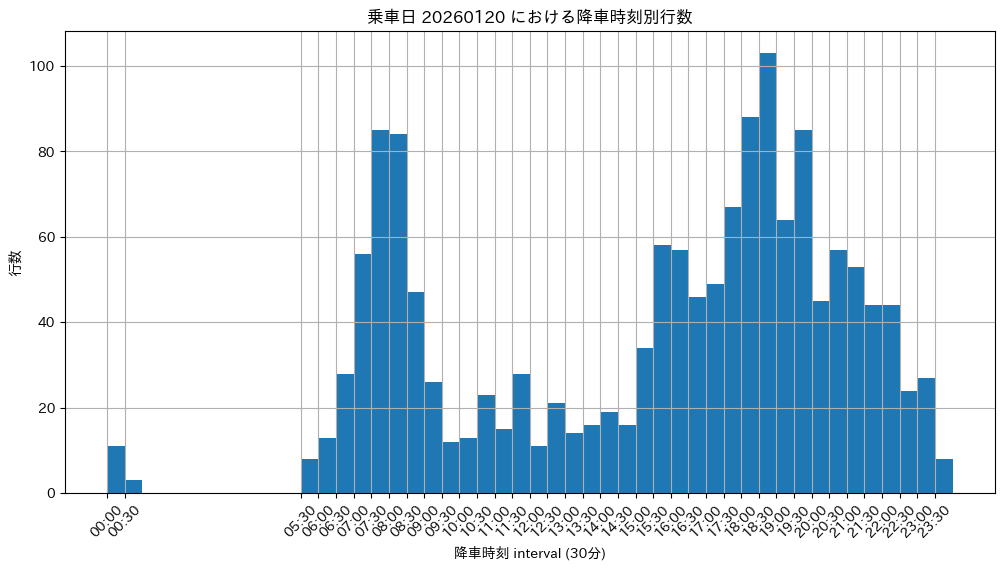

In [120]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20260120
)

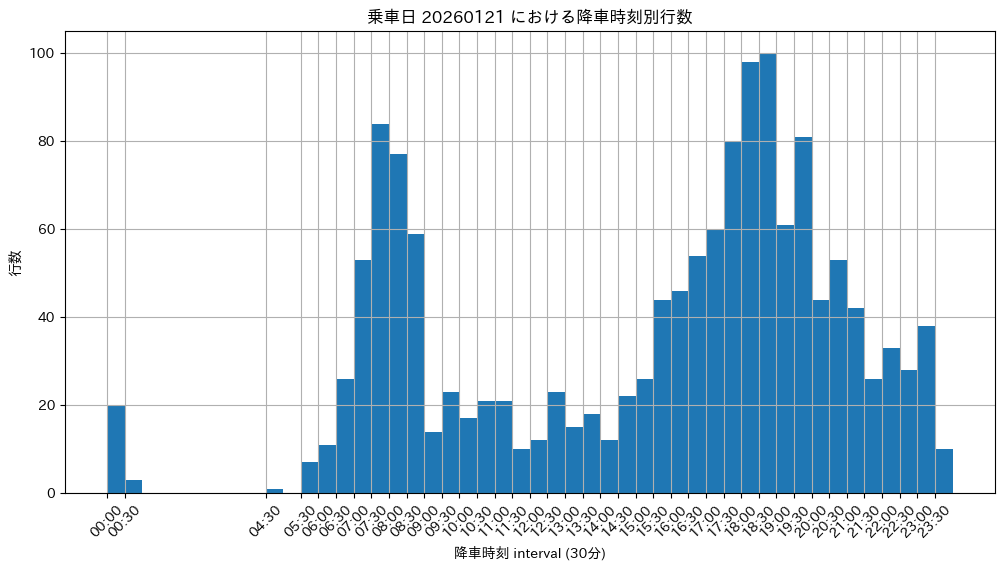

In [121]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20260121
)

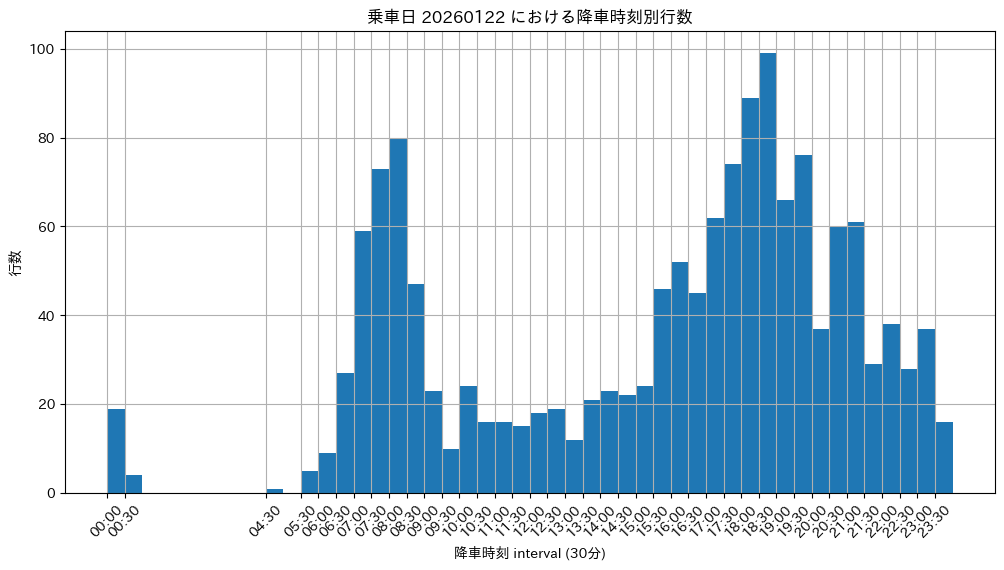

In [122]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20260122
)

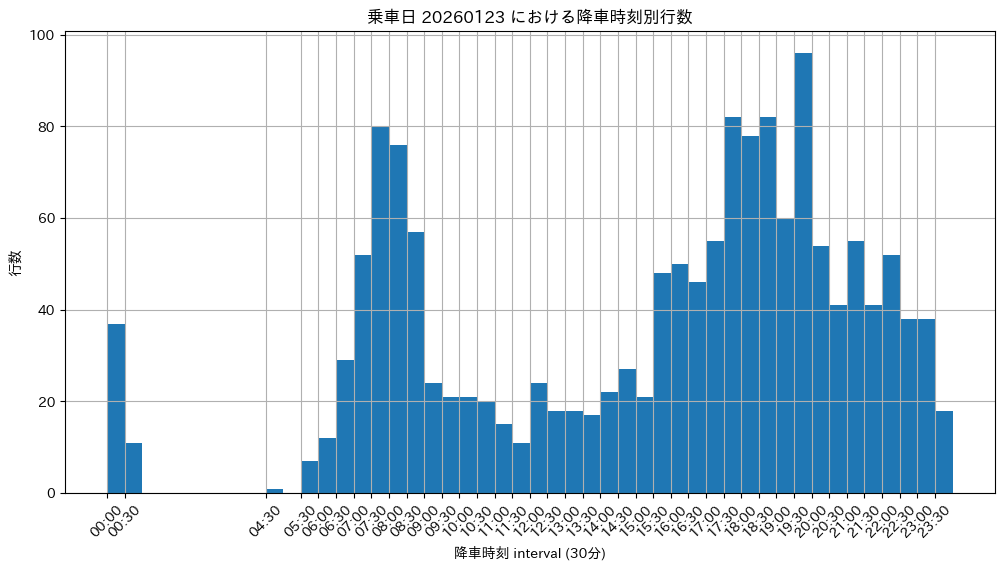

In [123]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20260123
)

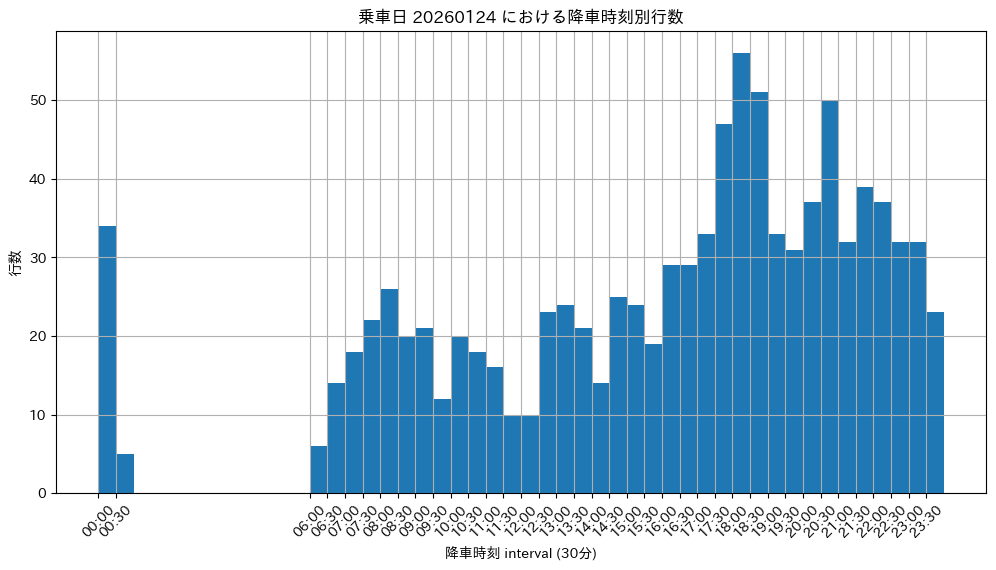

In [124]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20260124
)

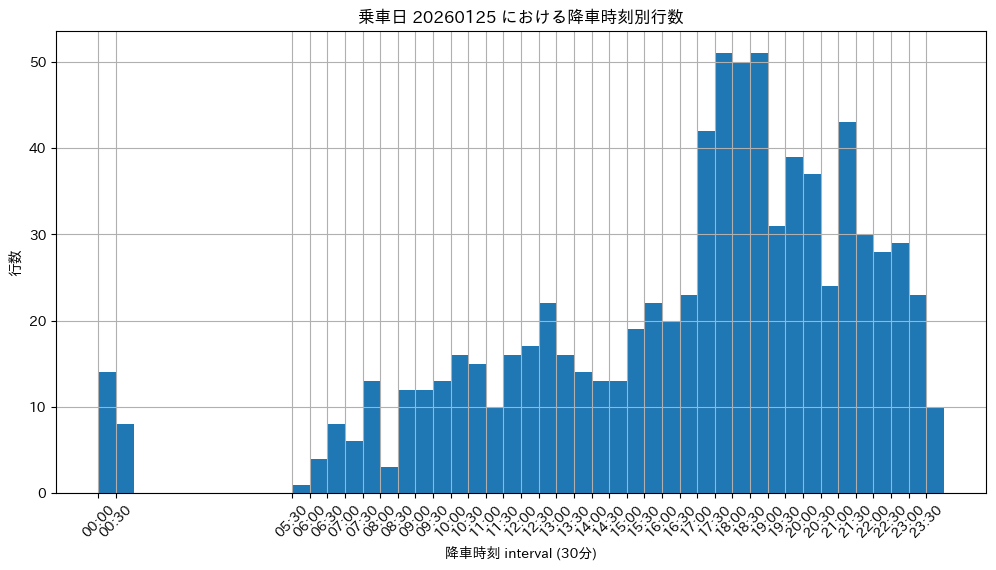

In [125]:
plot_dropoff_count_by_time(
    df = df_filtered_turuhara,
    target_date=20260125
)

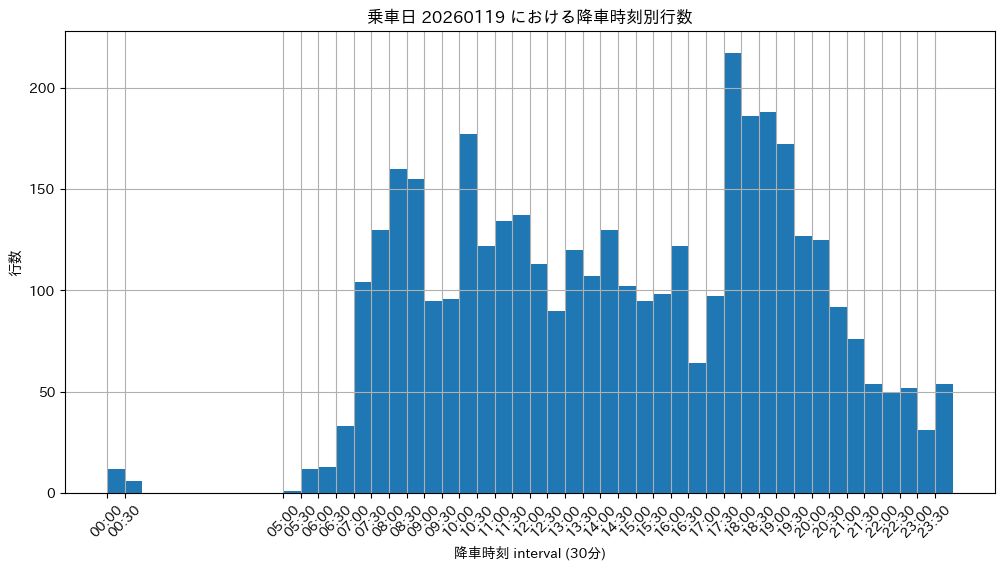

In [126]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20260119
)

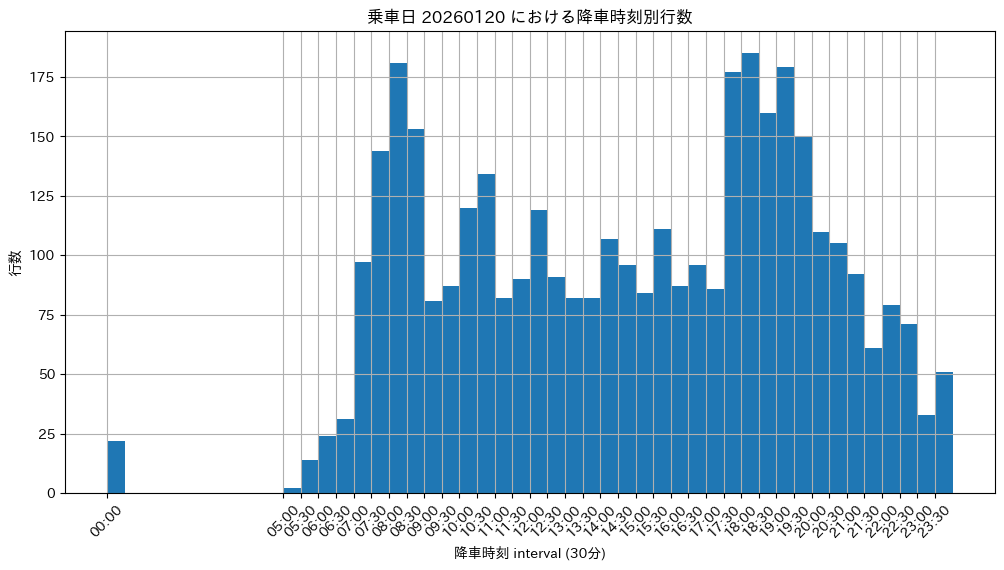

In [127]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20260120
)

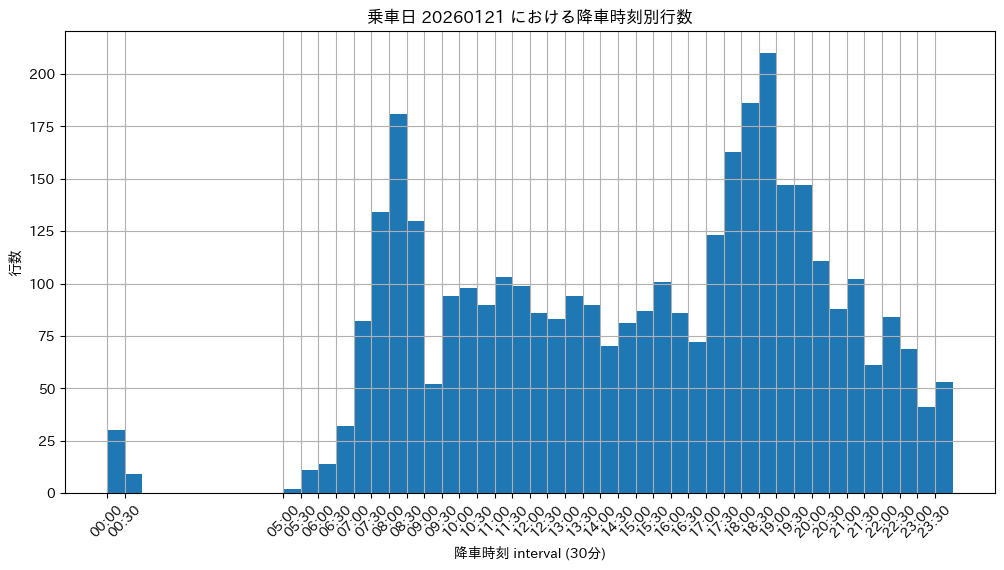

In [128]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20260121
)

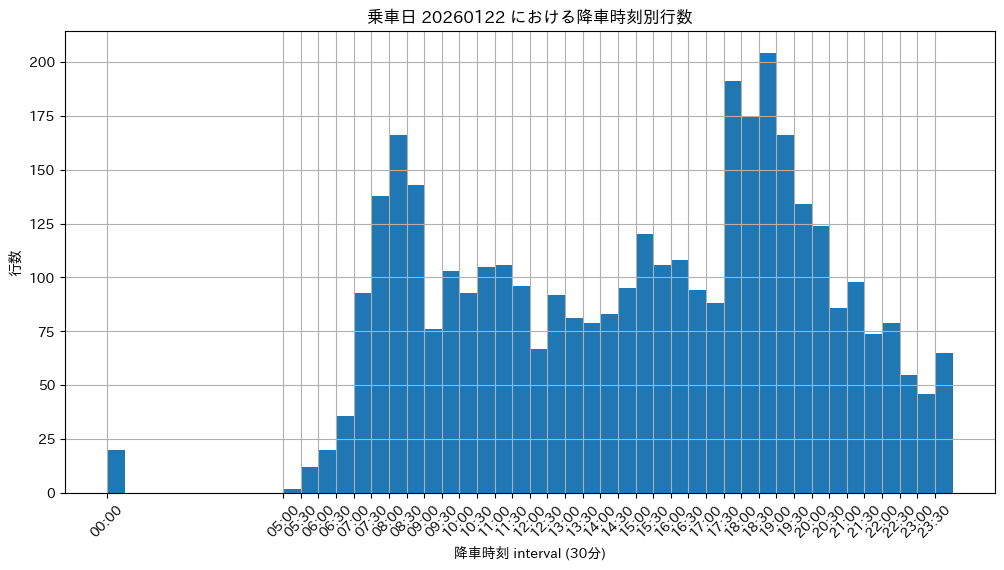

In [129]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20260122
)

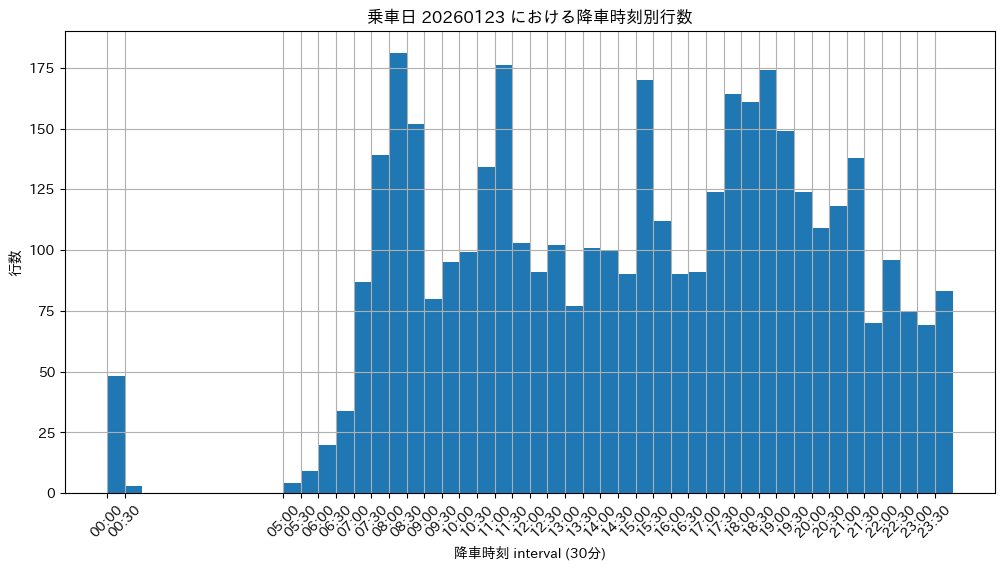

In [130]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20260123
)

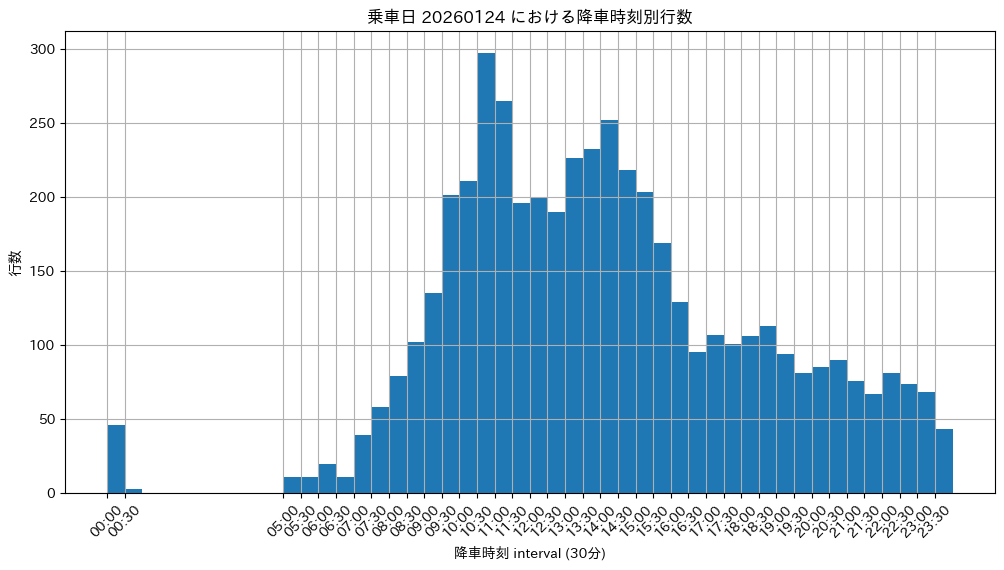

In [131]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20260124
)

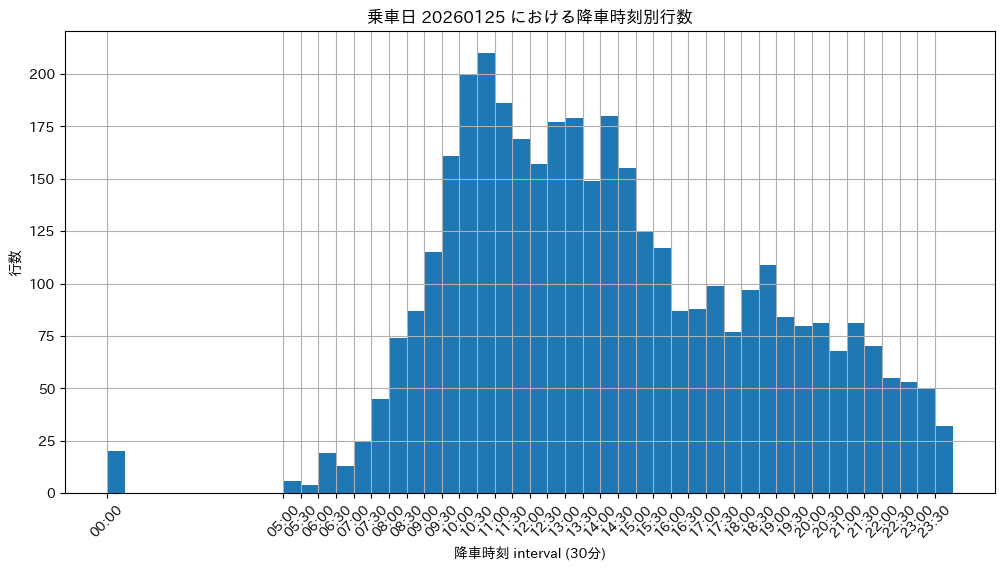

In [132]:
plot_dropoff_count_by_time(
    df = df_filtered_sumiyoshi,
    target_date=20260125
)